<a href="https://colab.research.google.com/github/NanditaPatil-dotcom/PhysSAE/blob/main/PhysSAE_Additional_PDEs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup

In [1]:
import os, time, math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA

# reproducibility
torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(4)

# publication style
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 220,
    "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
})

os.makedirs("artifacts", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# hyperparams
HIDDEN = 40        # PINN hidden width
N_LAYERS = 4       # number of hidden linear layers
DICT = 128         # SAE dictionary size (overcomplete 3.2x)
LAM_L1 = 5e-2      # SAE sparsity penalty
SAE_EPOCHS = 500
PINN_ITERS = 4000


# 2. PINN architecture


In [2]:
class PINN(nn.Module):
    def __init__(self, out_dim=1, layers=None):
        super().__init__()

        layers = layers or ([2] +[HIDDEN]*N_LAYERS +[out_dim])

        self.net = nn.ModuleList(
            [nn.Linear(layers[i], layers[i+1])
             for i in range(len(layers)-1)]
        )

        self.act = nn.Tanh()

        for m in self.net:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

        self._hidden = None

    def forward(self,x,t):
        h = torch.cat([x,t],dim=1)

        for layer in self.net[:-1]:
            h = self.act(layer(h))

        self._hidden = h

        return self.net[-1](h)


# 3. Training PINN

In [3]:
def train_pinn(loss_fn, n_iter=PINN_ITERS, log_every=400, tag="pinn",out_dim=1):
    model = PINN(out_dim=out_dim)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = []; t0 = time.time()
    for it in range(n_iter):
        opt.zero_grad()
        loss, parts = loss_fn(model)
        loss.backward(); opt.step()
        hist.append(parts)
        if it % log_every == 0:
            print(f"[{tag}] it {it:5d} | bc {parts[0]:.2e} ic {parts[1]:.2e} f {parts[2]:.2e} | {time.time()-t0:.0f}s")
    print(f"[{tag}] total {time.time()-t0:.0f}s")
    return model, np.array(hist)

# 4. Train on PDEs

## 1. Train the Burgers PINN



In [4]:
nu = 0.01/np.pi
def burgers_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -torch.ones(n_b,1); x_b2 = torch.ones(n_b,1); t_b = torch.rand(n_b,1)
    x_i = torch.rand(n_i,1)*2-1; t_i = torch.zeros(n_i,1); u_i = -torch.sin(np.pi*x_i)
    x_f = torch.rand(n_f,1)*2-1; t_f = torch.rand(n_f,1)
    u_b1, u_b2, u_ip = model(x_b1, t_b), model(x_b2, t_b), model(x_i, t_i)
    xfg, tfg = x_f.clone().requires_grad_(True), t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u, tfg, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg, torch.ones_like(u_x), create_graph=True)[0]
    r = u_t + u*u_x - nu*u_xx
    l_bc = (u_b1**2).mean() + (u_b2**2).mean()
    l_ic = ((u_ip - u_i)**2).mean()
    l_f  = (r**2).mean()
    return 100*l_bc + 100*l_ic + l_f, (l_bc.item(), l_ic.item(), l_f.item())

if os.path.exists("artifacts/burgers_pinn.pt"):
    pinn_b = PINN(out_dim=1); pinn_b.load_state_dict(torch.load("artifacts/burgers_pinn.pt"))
    hist_b = np.load("artifacts/burgers_hist.npy")
    print("Loaded cached Burgers PINN.")
else:
    pinn_b, hist_b = train_pinn(burgers_loss, tag="burgers")
    torch.save(pinn_b.state_dict(), "artifacts/burgers_pinn.pt")
    np.save("artifacts/burgers_hist.npy", hist_b)


[burgers] it     0 | bc 1.10e-02 ic 5.70e-01 f 1.29e-02 | 1s
[burgers] it   400 | bc 1.10e-03 ic 8.67e-03 f 7.04e-01 | 40s
[burgers] it   800 | bc 4.77e-04 ic 7.83e-04 f 4.56e-01 | 78s
[burgers] it  1200 | bc 3.47e-04 ic 3.61e-04 f 4.19e-01 | 123s
[burgers] it  1600 | bc 1.82e-04 ic 1.95e-04 f 4.21e-01 | 165s
[burgers] it  2000 | bc 1.11e-04 ic 2.32e-04 f 4.05e-01 | 207s
[burgers] it  2400 | bc 2.06e-04 ic 1.84e-04 f 4.13e-01 | 250s
[burgers] it  2800 | bc 4.28e-05 ic 1.25e-04 f 3.53e-01 | 292s
[burgers] it  3200 | bc 1.79e-04 ic 2.56e-04 f 3.65e-01 | 332s
[burgers] it  3600 | bc 1.68e-03 ic 4.63e-04 f 3.67e-01 | 373s
[burgers] total 416s


## 2. Train the Allen–Cahn PINN


In [5]:
D_AC = 1e-4
def allencahn_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    t_b = torch.rand(n_b,1)
    x_bl = -torch.ones(n_b,1); x_br = torch.ones(n_b,1)
    x_i = torch.rand(n_i,1)*2-1; t_i = torch.zeros(n_i,1)
    u_i = (x_i**2) * torch.cos(np.pi*x_i)
    x_f = torch.rand(n_f,1)*2-1; t_f = torch.rand(n_f,1)
    # periodic BC: u(-1,t)=u(1,t) and u_x(-1,t)=u_x(1,t)
    xbl_g, xbr_g = x_bl.clone().requires_grad_(True), x_br.clone().requires_grad_(True)
    u_bl, u_br = model(xbl_g, t_b), model(xbr_g, t_b)
    u_bl_x = torch.autograd.grad(u_bl, xbl_g, torch.ones_like(u_bl), create_graph=True)[0]
    u_br_x = torch.autograd.grad(u_br, xbr_g, torch.ones_like(u_br), create_graph=True)[0]
    l_bc = ((u_bl-u_br)**2).mean() + ((u_bl_x-u_br_x)**2).mean()
    u_ip = model(x_i, t_i); l_ic = ((u_ip - u_i)**2).mean()
    xfg, tfg = x_f.clone().requires_grad_(True), t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u, tfg, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg, torch.ones_like(u_x), create_graph=True)[0]
    r = u_t - D_AC*u_xx + 5.0*u**3 - 5.0*u
    l_f = (r**2).mean()
    return 100*l_bc + 100*l_ic + l_f, (l_bc.item(), l_ic.item(), l_f.item())

if os.path.exists("artifacts/allencahn_pinn.pt"):
    pinn_a = PINN(out_dim=1); pinn_a.load_state_dict(torch.load("artifacts/allencahn_pinn.pt"))
    hist_a = np.load("artifacts/allencahn_hist.npy")
    print("Loaded cached Allen-Cahn PINN.")
else:
    pinn_a, hist_a = train_pinn(allencahn_loss, tag="allencahn")
    torch.save(pinn_a.state_dict(), "artifacts/allencahn_pinn.pt")
    np.save("artifacts/allencahn_hist.npy", hist_a)


[allencahn] it     0 | bc 3.69e-02 ic 1.12e-01 f 1.38e-01 | 0s
[allencahn] it   400 | bc 2.12e-03 ic 2.07e-02 f 1.16e+00 | 46s
[allencahn] it   800 | bc 8.14e-04 ic 3.23e-03 f 1.07e+00 | 93s
[allencahn] it  1200 | bc 4.38e-04 ic 1.30e-03 f 1.03e+00 | 137s
[allencahn] it  1600 | bc 6.09e-04 ic 7.82e-04 f 9.85e-01 | 184s
[allencahn] it  2000 | bc 3.04e-04 ic 6.11e-04 f 9.78e-01 | 232s
[allencahn] it  2400 | bc 8.05e-05 ic 7.36e-04 f 1.09e+00 | 279s
[allencahn] it  2800 | bc 2.66e-04 ic 8.68e-04 f 9.66e-01 | 326s
[allencahn] it  3200 | bc 1.38e-04 ic 1.01e-03 f 9.97e-01 | 372s
[allencahn] it  3600 | bc 8.21e-05 ic 9.01e-04 f 9.23e-01 | 421s
[allencahn] total 468s


## 3. Heat Equation

In [6]:
def heat_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -torch.ones(n_b,1)
    x_b2 =  torch.ones(n_b,1)
    t_b = torch.rand(n_b,1)
    u_b1 = model(x_b1, t_b)
    u_b2 = model(x_b2, t_b)
    x_i = 2*torch.rand(n_i,1) - 1
    t_i = torch.zeros(n_i,1)
    u_i_true = torch.exp(-5*x_i**2)
    u_i = model(x_i, t_i)
    x_f = 2*torch.rand(n_f,1) - 1
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u,tfg,torch.ones_like(u),create_graph=True)[0]
    u_x = torch.autograd.grad(u,xfg,torch.ones_like(u),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x,xfg,torch.ones_like(u_x),create_graph=True)[0]

    r = u_t - u_xx

    l_bc = (u_b1**2).mean() + (u_b2**2).mean()
    l_ic = ((u_i - u_i_true)**2).mean()
    l_f = (r**2).mean()
    total = 100*l_bc + 100*l_ic + l_f
    return total, (l_bc.item(),l_ic.item(),l_f.item())

if os.path.exists("artifacts/heat_pinn.pt"):
    pinn_h = PINN(out_dim=1)
    pinn_h.load_state_dict(torch.load("artifacts/heat_pinn.pt"))
    hist_h = np.load("artifacts/heat_hist.npy")
    print("Loaded cached Heat PINN.")
else:
    pinn_h, hist_h = train_pinn(heat_loss,tag="heat")
    torch.save(pinn_h.state_dict(),"artifacts/heat_pinn.pt")
    np.save("artifacts/heat_hist.npy",hist_h)

[heat] it     0 | bc 1.51e-01 ic 3.47e-01 f 1.63e-01 | 0s
[heat] it   400 | bc 5.80e-04 ic 2.92e-03 f 3.62e-01 | 45s
[heat] it   800 | bc 4.20e-04 ic 7.76e-04 f 1.70e-01 | 91s
[heat] it  1200 | bc 2.65e-04 ic 4.71e-04 f 9.77e-02 | 135s
[heat] it  1600 | bc 1.42e-04 ic 2.70e-04 f 5.95e-02 | 181s
[heat] it  2000 | bc 8.54e-05 ic 1.85e-04 f 3.60e-02 | 225s
[heat] it  2400 | bc 6.82e-05 ic 1.51e-04 f 2.13e-02 | 269s
[heat] it  2800 | bc 5.51e-05 ic 6.39e-05 f 1.72e-02 | 312s
[heat] it  3200 | bc 2.23e-04 ic 7.96e-05 f 1.40e-02 | 356s
[heat] it  3600 | bc 1.08e-05 ic 3.01e-05 f 1.22e-02 | 400s
[heat] total 443s


## 4. schrodinger equation - single soliton

In [7]:
def schrodinger_loss_single(model):

    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -5*torch.ones(n_b,1)
    x_b2 =  5*torch.ones(n_b,1)
    t_b  = torch.rand(n_b,1)
    uv_b1 = model(x_b1,t_b)
    uv_b2 = model(x_b2,t_b)
    u_b1 = uv_b1[:,0:1]
    v_b1 = uv_b1[:,1:2]
    u_b2 = uv_b2[:,0:1]
    v_b2 = uv_b2[:,1:2]

    x_i = -5 + 10*torch.rand(n_i,1)
    t_i = torch.zeros(n_i,1)

    uv_i = model(x_i,t_i)

    u_i = uv_i[:,0:1]
    v_i = uv_i[:,1:2]

    u_true = 2.0 / torch.cosh(x_i)
    v_true = torch.zeros_like(x_i)

    x_f = -5 + 10*torch.rand(n_f,1)
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    uv = model(xfg,tfg)
    u = uv[:,0:1]
    v = uv[:,1:2]

    u_t = torch.autograd.grad(u, tfg,torch.ones_like(u),create_graph=True)[0]
    v_t = torch.autograd.grad(v, tfg,torch.ones_like(v),create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg,torch.ones_like(u),create_graph=True)[0]
    v_x = torch.autograd.grad(v, xfg,torch.ones_like(v),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg,torch.ones_like(u_x),create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, xfg,torch.ones_like(v_x),create_graph=True)[0]
    amp2 = u*u + v*v
    r_u = u_t + 0.5*v_xx + amp2*v
    r_v = v_t - 0.5*u_xx - amp2*u
    l_bc = ((u_b1**2).mean()+ (v_b1**2).mean()+ (u_b2**2).mean()+ (v_b2**2).mean())
    l_ic = (((u_i-u_true)**2).mean()+ ((v_i-v_true)**2).mean())
    l_f = ((r_u**2).mean()+ (r_v**2).mean())
    total = 100*l_bc + 100*l_ic + l_f

    return total, (l_bc.item(),l_ic.item(),l_f.item())


if os.path.exists("artifacts/schrodinger_pinn_single.pt"):
    pinn_s_s = PINN(out_dim=2)
    pinn_s_s.load_state_dict(torch.load("artifacts/schrodinger_pinn_single.pt"))
    hist_s_s = np.load("artifacts/schrodinger_hist_single.npy")
    print("Loaded cached Schrödinger single PINN.")

else:
    pinn_s_s, hist_s_s = train_pinn(schrodinger_loss_single,tag="schrodinger single",out_dim=2)
    torch.save(pinn_s_s.state_dict(),"artifacts/schrodinger_pinn_single.pt")
    np.save("artifacts/schrodinger_hist_single.npy",hist_s_s)

[schrodinger single] it     0 | bc 8.39e-01 ic 1.03e+00 f 2.95e-02 | 0s
[schrodinger single] it   400 | bc 2.24e-04 ic 1.20e-03 f 6.64e-01 | 75s
[schrodinger single] it   800 | bc 7.24e-05 ic 5.37e-04 f 4.29e-01 | 148s
[schrodinger single] it  1200 | bc 4.39e-05 ic 2.20e-04 f 3.39e-01 | 214s
[schrodinger single] it  1600 | bc 4.14e-05 ic 1.41e-04 f 2.27e-01 | 279s
[schrodinger single] it  2000 | bc 5.14e-05 ic 1.62e-04 f 1.91e-01 | 344s
[schrodinger single] it  2400 | bc 1.97e-04 ic 1.93e-04 f 1.63e-01 | 407s
[schrodinger single] it  2800 | bc 1.89e-04 ic 1.19e-04 f 1.65e-01 | 471s
[schrodinger single] it  3200 | bc 3.28e-05 ic 7.29e-05 f 1.59e-01 | 535s
[schrodinger single] it  3600 | bc 5.95e-05 ic 8.82e-05 f 1.37e-01 | 599s
[schrodinger single] total 662s


## 5. schrodinger equation - moving soliton

In [8]:
def schrodinger_loss_moving(model):

    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -5*torch.ones(n_b,1)
    x_b2 =  5*torch.ones(n_b,1)
    t_b  = torch.rand(n_b,1)
    uv_b1 = model(x_b1,t_b)
    uv_b2 = model(x_b2,t_b)
    u_b1 = uv_b1[:,0:1]
    v_b1 = uv_b1[:,1:2]
    u_b2 = uv_b2[:,0:1]
    v_b2 = uv_b2[:,1:2]
    x_i = -5 + 10*torch.rand(n_i,1)
    t_i = torch.zeros(n_i,1)

    uv_i = model(x_i,t_i)

    u_i = uv_i[:,0:1]
    v_i = uv_i[:,1:2]

    eta = 2.0
    v0  = 2.0

    amp0 = eta / torch.cosh(eta*x_i)

    u_true = amp0 * torch.cos(v0*x_i)
    v_true = amp0 * torch.sin(v0*x_i)
    x_f = -5 + 10*torch.rand(n_f,1)
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    uv = model(xfg,tfg)
    u = uv[:,0:1]
    v = uv[:,1:2]

    u_t = torch.autograd.grad(u, tfg,torch.ones_like(u),create_graph=True)[0]
    v_t = torch.autograd.grad(v, tfg,torch.ones_like(v),create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg,torch.ones_like(u),create_graph=True)[0]
    v_x = torch.autograd.grad(v, xfg,torch.ones_like(v),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg,torch.ones_like(u_x),create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, xfg,torch.ones_like(v_x),create_graph=True)[0]
    amp2 = u*u + v*v
    r_u = u_t + 0.5*v_xx + amp2*v
    r_v = v_t - 0.5*u_xx - amp2*u
    l_bc = ((u_b1**2).mean()+ (v_b1**2).mean()+ (u_b2**2).mean()+ (v_b2**2).mean())
    l_ic = (((u_i-u_true)**2).mean()+ ((v_i-v_true)**2).mean())
    l_f = ((r_u**2).mean()+ (r_v**2).mean())
    total = 100*l_bc + 100*l_ic + l_f

    return total, (l_bc.item(),l_ic.item(),l_f.item())


try:
    if os.path.exists("artifacts/schrodinger_pinn_moving.pt") and \
       os.path.exists("artifacts/schrodinger_hist_moving.npy"):
        pinn_s_m = PINN(out_dim=2)
        pinn_s_m.load_state_dict(torch.load("artifacts/schrodinger_pinn_moving.pt"))
        hist_s_m = np.load("artifacts/schrodinger_hist_moving.npy")
        print("Loaded cached Schrödinger moving PINN.")

    else:
        pinn_s_m, hist_s_m = train_pinn(schrodinger_loss_moving,tag="schrodinger moving",out_dim=2)
        torch.save(pinn_s_m.state_dict(),"artifacts/schrodinger_pinn_moving.pt")
        np.save("artifacts/schrodinger_hist_moving.npy",hist_s_m)

except FileNotFoundError:
    print("Cached files not found or inaccessible; retraining Schrödinger moving PINN.")
    pinn_s_m, hist_s_m = train_pinn(schrodinger_loss_moving,tag="schrodinger moving",out_dim=2)
    torch.save(pinn_s_m.state_dict(),"artifacts/schrodinger_pinn_moving.pt")
    np.save("artifacts/schrodinger_hist_moving.npy",hist_s_m)

[schrodinger moving] it     0 | bc 4.17e-01 ic 4.80e-01 f 8.31e-02 | 0s
[schrodinger moving] it   400 | bc 4.70e-04 ic 5.20e-03 f 7.07e-01 | 63s
[schrodinger moving] it   800 | bc 2.86e-04 ic 2.06e-03 f 3.42e-01 | 126s
[schrodinger moving] it  1200 | bc 2.37e-04 ic 8.85e-04 f 2.05e-01 | 189s
[schrodinger moving] it  1600 | bc 5.40e-05 ic 3.26e-04 f 1.88e-01 | 254s
[schrodinger moving] it  2000 | bc 3.17e-05 ic 2.44e-04 f 1.39e-01 | 318s
[schrodinger moving] it  2400 | bc 4.34e-05 ic 1.52e-04 f 1.25e-01 | 382s
[schrodinger moving] it  2800 | bc 1.61e-05 ic 7.71e-05 f 9.61e-02 | 445s
[schrodinger moving] it  3200 | bc 2.75e-05 ic 7.81e-05 f 7.92e-02 | 509s
[schrodinger moving] it  3600 | bc 1.77e-05 ic 5.24e-05 f 7.90e-02 | 573s
[schrodinger moving] total 636s


## 6. Convection equation

In [9]:
def convection_loss(model, beta):

    n_b, n_i, n_f = 100, 100, 2500

    # periodic BC
    t_b = torch.rand(n_b,1)
    x_bl = -torch.ones(n_b,1)
    x_br =  torch.ones(n_b,1)
    u_bl = model(x_bl, t_b)
    u_br = model(x_br, t_b)

    # periodic derivative BC
    xbl_g = x_bl.clone().requires_grad_(True)
    xbr_g = x_br.clone().requires_grad_(True)

    u_bl_g = model(xbl_g, t_b)
    u_br_g = model(xbr_g, t_b)

    u_bl_x = torch.autograd.grad(u_bl_g,xbl_g,torch.ones_like(u_bl_g),create_graph=True)[0]
    u_br_x = torch.autograd.grad(u_br_g,xbr_g,torch.ones_like(u_br_g),create_graph=True)[0]
    l_bc = ((u_bl - u_br)**2).mean() + ((u_bl_x - u_br_x)**2).mean()

    # initial condition

    x_i = 2*torch.rand(n_i,1) - 1
    t_i = torch.zeros(n_i,1)

    u_true = torch.sin(np.pi*x_i)

    u_i = model(x_i,t_i)

    l_ic = ((u_i - u_true)**2).mean()

    # residual points

    x_f = 2*torch.rand(n_f,1) - 1
    t_f = torch.rand(n_f,1)

    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)

    u = model(xfg,tfg)
    u_t = torch.autograd.grad(u,tfg,torch.ones_like(u),create_graph=True)[0]
    u_x = torch.autograd.grad(u,xfg,torch.ones_like(u),create_graph=True)[0]

    r = u_t + beta*u_x
    l_f = (r**2).mean()
    total = 100*l_bc + 100*l_ic + l_f
    return total, (l_bc.item(),l_ic.item(),l_f.item())

BETAS = [1,50]

conv_models = {}
conv_hists  = {}

for beta in BETAS:

    fname_model = f"artifacts/convection_beta{beta}.pt"
    fname_hist  = f"artifacts/convection_beta{beta}_hist.npy"

    if os.path.exists(fname_model):

        model = PINN(out_dim=1)
        model.load_state_dict(torch.load(fname_model))
        hist = np.load(fname_hist)
        print(f"Loaded cached convection PINN beta={beta}")

    else:

        loss_fn = lambda m, b=beta: convection_loss(m,b)
        model, hist = train_pinn(loss_fn,tag=f"conv_beta{beta}")
        torch.save(model.state_dict(),fname_model)
        np.save(fname_hist,hist)

    conv_models[beta] = model
    conv_hists[beta]  = hist

[conv_beta1] it     0 | bc 1.22e+00 ic 9.77e-01 f 3.24e-01 | 0s
[conv_beta1] it   400 | bc 2.50e-03 ic 1.11e-02 f 1.02e+00 | 25s
[conv_beta1] it   800 | bc 5.66e-04 ic 1.25e-03 f 8.46e-01 | 50s
[conv_beta1] it  1200 | bc 5.37e-04 ic 1.04e-03 f 6.57e-01 | 75s
[conv_beta1] it  1600 | bc 9.09e-04 ic 6.61e-04 f 5.79e-01 | 100s
[conv_beta1] it  2000 | bc 1.37e-03 ic 6.40e-04 f 5.13e-01 | 125s
[conv_beta1] it  2400 | bc 5.82e-04 ic 1.55e-04 f 4.44e-01 | 150s
[conv_beta1] it  2800 | bc 2.48e-04 ic 1.73e-04 f 3.81e-01 | 175s
[conv_beta1] it  3200 | bc 4.44e-04 ic 1.89e-04 f 3.44e-01 | 199s
[conv_beta1] it  3600 | bc 5.65e-04 ic 3.01e-04 f 2.96e-01 | 224s
[conv_beta1] total 250s
[conv_beta50] it     0 | bc 3.06e-01 ic 7.31e-01 f 1.98e+02 | 0s
[conv_beta50] it   400 | bc 6.78e-03 ic 5.16e-01 f 1.98e+00 | 25s
[conv_beta50] it   800 | bc 5.65e-02 ic 1.88e-01 f 1.65e+00 | 50s
[conv_beta50] it  1200 | bc 3.53e-02 ic 8.66e-02 f 4.59e+00 | 75s
[conv_beta50] it  1600 | bc 1.10e-02 ic 3.78e-02 f 9.97e-0

# 5. Evaluate All PINNs on a dense grid



In [10]:
nx, nt = 256, 100
xs = torch.linspace(-1, 1, nx).reshape(-1,1)
ts = torch.linspace(0, 1, nt).reshape(-1,1)
X, T = torch.meshgrid(xs.squeeze(), ts.squeeze(), indexing='ij')
XF, TF = X.reshape(-1,1), T.reshape(-1,1)
np.save("artifacts/grid_x.npy", xs.numpy().squeeze())
np.save("artifacts/grid_t.npy", ts.numpy().squeeze())

def eval_pinn_and_hidden(model):
    with torch.no_grad():
        U = model(XF, TF).reshape(nx, nt).numpy()
        H = model._hidden.detach().reshape(nx, nt, HIDDEN).numpy()
    return U, H

def eval_schrodinger_and_hidden(model):

    with torch.no_grad():
        UV = model(XF,TF)
        U = UV[:,0].reshape(nx,nt).numpy()
        V = UV[:,1].reshape(nx,nt).numpy()
        H = (model._hidden.detach().reshape(nx,nt,HIDDEN).numpy())
    return U,V,H

U_b, H_b = eval_pinn_and_hidden(pinn_b)
np.save("artifacts/burgers_U.npy", U_b)
np.save("artifacts/burgers_H.npy", H_b)

U_a, H_a = eval_pinn_and_hidden(pinn_a)
np.save("artifacts/allencahn_U.npy", U_a)
np.save("artifacts/allencahn_H.npy", H_a)

U_h, H_h = eval_pinn_and_hidden(pinn_h)
np.save("artifacts/heat_U.npy",U_h)
np.save("artifacts/heat_H.npy",H_h)

U_s_s, V_s_s, H_s_s = eval_schrodinger_and_hidden(pinn_s_s)
np.save("artifacts/schrodinger_u_single.npy", U_s_s)
np.save("artifacts/schrodinger_v_single.npy", V_s_s)
np.save("artifacts/schrodinger_H_single.npy", H_s_s)
AMP_s_s = np.sqrt(U_s_s**2 + V_s_s**2)
np.save("artifacts/schrodinger_amp_single.npy",AMP_s_s)
PHI_s_s = np.arctan2(V_s_s, U_s_s)
np.save("artifacts/schrodinger_phi_single.npy",PHI_s_s)

U_s_m, V_s_m, H_s_m = eval_schrodinger_and_hidden(pinn_s_m)
np.save("artifacts/schrodinger_u_moving.npy", U_s_m)
np.save("artifacts/schrodinger_v_moving.npy", V_s_m)
np.save("artifacts/schrodinger_H_moving.npy", H_s_m)
AMP_s_m = np.sqrt(U_s_m**2 + V_s_m**2)
np.save("artifacts/schrodinger_amp_moving.npy",AMP_s_m)
PHI_s_m = np.arctan2(V_s_m, U_s_m)
np.save("artifacts/schrodinger_phi_moving.npy",PHI_s_m)

# Successful convection (beta=1)
U_c1, H_c1 = eval_pinn_and_hidden(conv_models[1])
np.save("artifacts/convection_beta1_U.npy", U_c1)
np.save("artifacts/convection_beta1_H.npy", H_c1)

# Failed convection (beta=50)
U_c50, H_c50 = eval_pinn_and_hidden(conv_models[50])
np.save("artifacts/convection_beta50_U.npy", U_c50)
np.save("artifacts/convection_beta50_H.npy", H_c50)

print(f"Burgers   U range [{U_b.min():.3f}, {U_b.max():.3f}], H shape {H_b.shape}")
print(f"AllenCahn U range [{U_a.min():.3f}, {U_a.max():.3f}], H shape {H_a.shape}")
print(f"Heat     U range "f"[{U_h.min():.3f}, {U_h.max():.3f}], "f"H shape {H_h.shape}")
print("Schrodinger-single:", U_s_s.shape, V_s_s.shape, H_s_s.shape)
print("Schrodinger-moving:", U_s_m.shape, V_s_m.shape, H_s_m.shape)
print(f"Conv β=1   U range [{U_c1.min():.3f}, {U_c1.max():.3f}], "f"H shape {H_c1.shape}")
print(f"Conv β=50  U range [{U_c50.min():.3f}, {U_c50.max():.3f}], "f"H shape {H_c50.shape}")



Burgers   U range [-0.975, 0.984], H shape (256, 100, 40)
AllenCahn U range [-0.916, 0.074], H shape (256, 100, 40)
Heat     U range [-0.011, 0.993], H shape (256, 100, 40)
Schrodinger-single: (256, 100) (256, 100) (256, 100, 40)
Schrodinger-moving: (256, 100) (256, 100) (256, 100, 40)
Conv β=1   U range [-0.992, 1.004], H shape (256, 100, 40)
Conv β=50  U range [-0.877, 0.891], H shape (256, 100, 40)


### Figure 1 — PINN solutions and training history

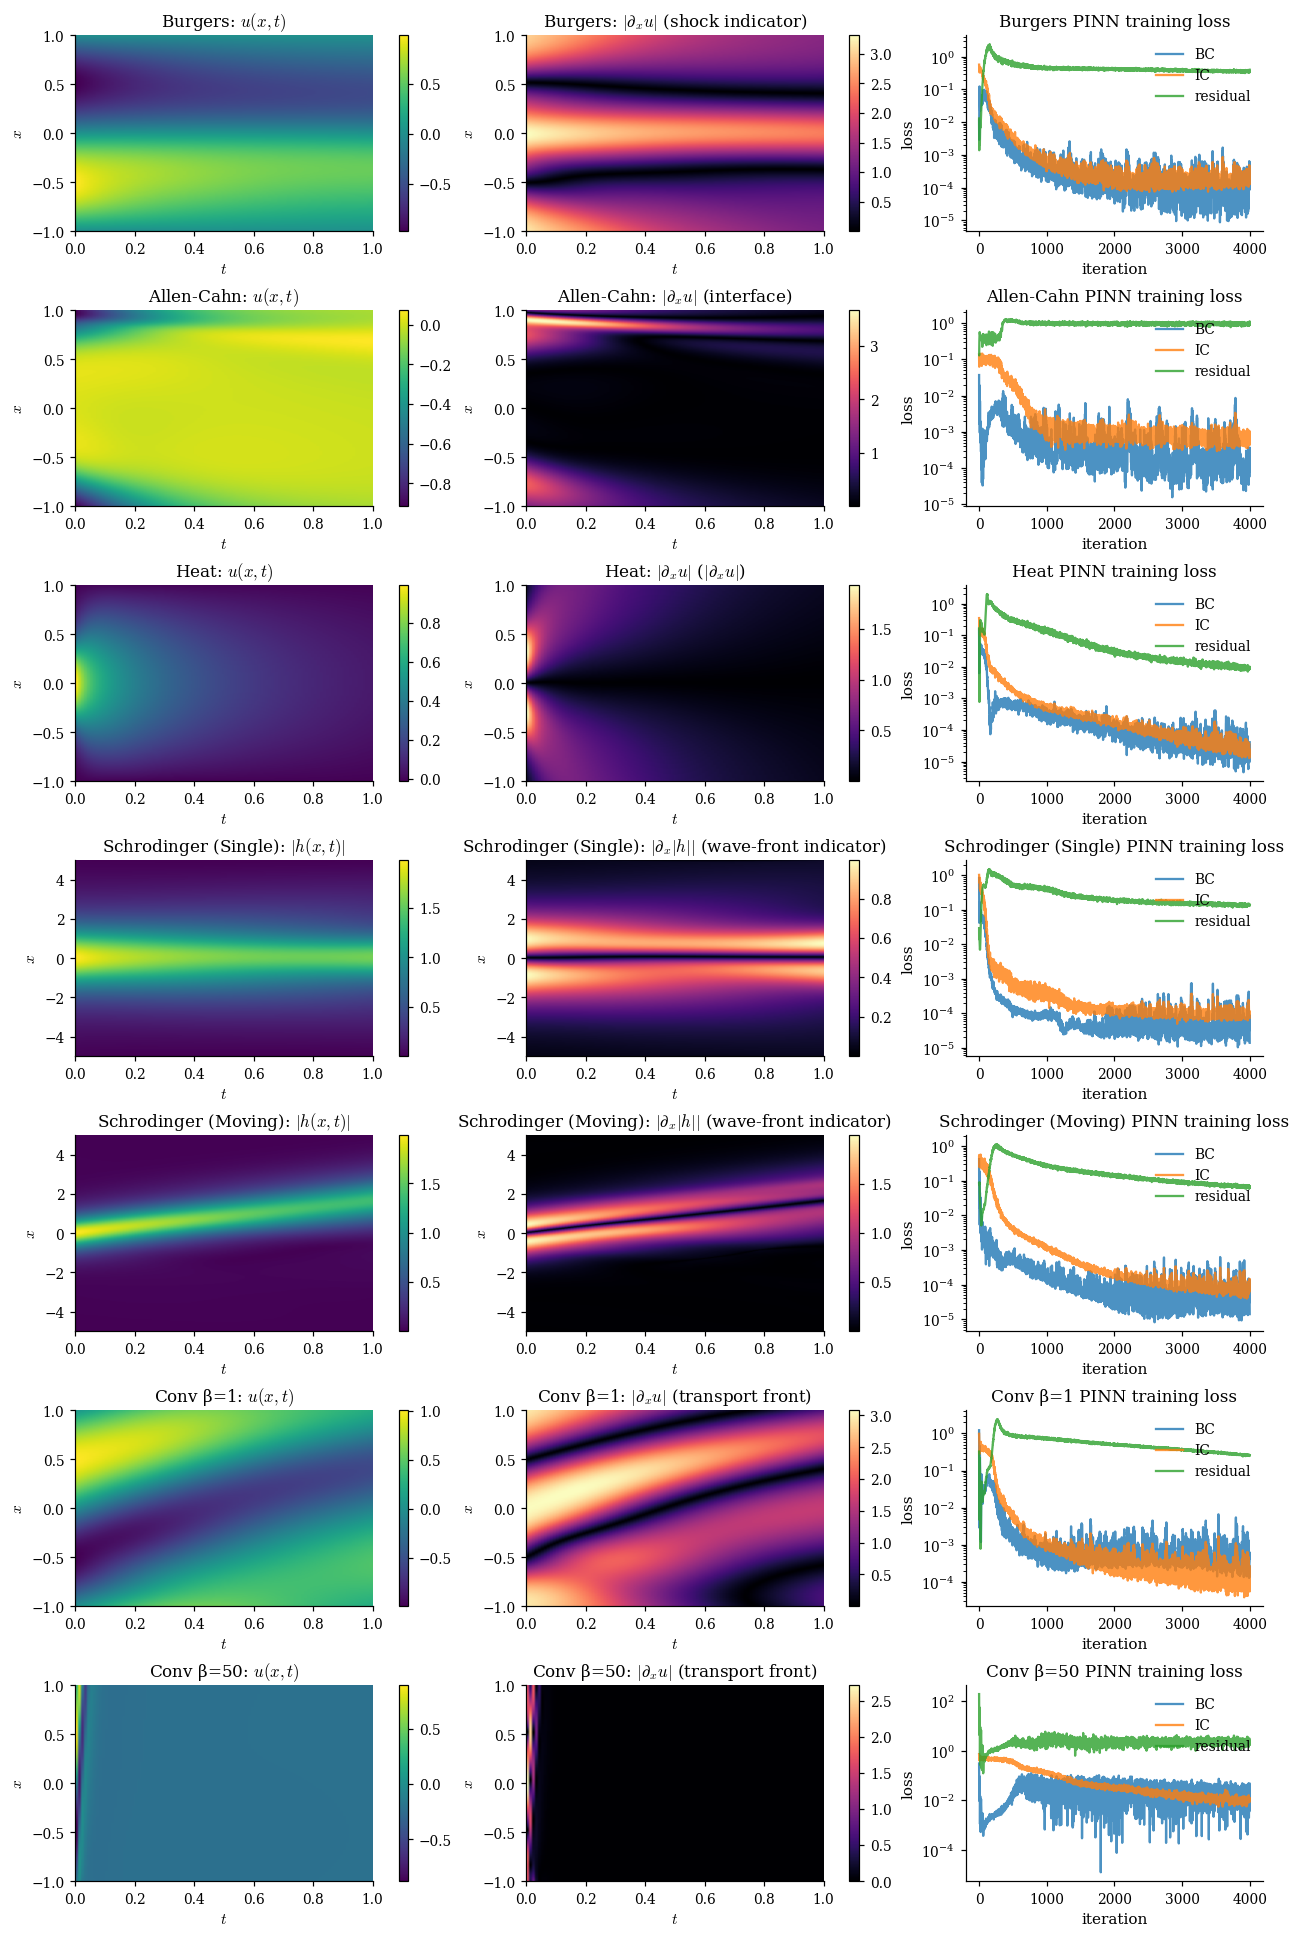

In [11]:
# Schrödinger evaluation on native domain [-5,5]


nx_s, nt_s = 256, 100
xs_s = torch.linspace(-5, 5, nx_s).reshape(-1,1)
ts_s = torch.linspace(0, 1, nt_s).reshape(-1,1)

Xs, Ts = torch.meshgrid(xs_s.squeeze(),ts_s.squeeze(),indexing="ij")
XF_s = Xs.reshape(-1,1)
TF_s = Ts.reshape(-1,1)

# ---------- Single soliton ----------
with torch.no_grad():

    UV = pinn_s_s(XF_s, TF_s)

    U_s_fig_single = UV[:,0].reshape(nx_s, nt_s).numpy()
    V_s_fig_single = UV[:,1].reshape(nx_s, nt_s).numpy()

AMP_s_fig_single = np.sqrt(U_s_fig_single**2 +V_s_fig_single**2)
UX_s_fig_single = np.abs(
    np.gradient(AMP_s_fig_single,xs_s.squeeze().numpy()[1]-xs_s.squeeze().numpy()[0],axis=0))

# ---------- Moving soliton ----------
with torch.no_grad():

    UV = pinn_s_m(XF_s, TF_s)
    U_s_fig_moving = UV[:,0].reshape(nx_s, nt_s).numpy()
    V_s_fig_moving = UV[:,1].reshape(nx_s, nt_s).numpy()

AMP_s_fig_moving = np.sqrt(U_s_fig_moving**2 +V_s_fig_moving**2)
UX_s_fig_moving = np.abs(
    np.gradient(AMP_s_fig_moving,xs_s.squeeze().numpy()[1]-xs_s.squeeze().numpy()[0],axis=0))

extent_s = [0,1,-5,5]

# ------------------------------------------------------------

xs_np = xs.numpy().squeeze()
ts_np = ts.numpy().squeeze()

extent = [ts_np.min(),ts_np.max(),xs_np.min(),xs_np.max()]
fig, axes = plt.subplots(7,3,figsize=(11.5,17.5),constrained_layout=True)

rows = [
    (U_b, hist_b, "Burgers"),
    (U_a, hist_a, "Allen-Cahn"),
    (U_h, hist_h, "Heat"),
    (AMP_s_fig_single,hist_s_s,"Schrodinger (Single)"),
    (AMP_s_fig_moving,hist_s_m,"Schrodinger (Moving)"),
    (U_c1,conv_hists[1],"Conv β=1"),
    (U_c50,conv_hists[50],"Conv β=50")]

for row, (U, hist, label) in enumerate(rows):

    # ----------------------------------------------------
    # domain
    # ----------------------------------------------------

    if label.startswith("Schrodinger"):
        current_extent = extent_s
    else:
        current_extent = extent

    # ----------------------------------------------------
    # solution
    # ----------------------------------------------------

    ax = axes[row,0]
    im = ax.imshow(U, extent=current_extent,origin="lower",aspect="auto",cmap="viridis")

    if label.startswith("Schrodinger"):
        ax.set_title(f"{label}: $|h(x,t)|$")
    else:
        ax.set_title(f"{label}: $u(x,t)$")

    ax.set_xlabel("$t$")
    ax.set_ylabel("$x$")

    plt.colorbar(im, ax=ax, fraction=0.046)

    # ----------------------------------------------------
    # gradient / wavefront
    # ----------------------------------------------------

    ax = axes[row,1]

    if label == "Schrodinger (Single)":
        ux = UX_s_fig_single

    elif label == "Schrodinger (Moving)":
        ux = UX_s_fig_moving

    else:
        ux = np.abs(np.gradient(U,xs_np[1]-xs_np[0],axis=0))

    im = ax.imshow(ux,extent=current_extent,origin="lower",aspect="auto",cmap="magma")

    if label == "Burgers":
        structure = "shock indicator"

    elif label == "Allen-Cahn":
        structure = "interface"

    elif label == "Heat":
        structure = r"$|\partial_x u|$"

    elif label.startswith("Conv"):
        structure = "transport front"

    else:
        structure = "wave-front indicator"

    if label.startswith("Schrodinger"):
        ax.set_title(
            f"{label}: $|\\partial_x|h||$ ({structure})"
        )
    else:
        ax.set_title(
            f"{label}: $|\\partial_x u|$ ({structure})"
        )

    ax.set_xlabel("$t$")
    ax.set_ylabel("$x$")

    plt.colorbar(im, ax=ax, fraction=0.046)

    # ----------------------------------------------------
    # training history
    # ----------------------------------------------------

    ax = axes[row,2]

    for j, lab in enumerate(["BC","IC","residual"]):
        ax.semilogy(hist[:,j],label=lab,alpha=0.8)

    ax.set_title(f"{label} PINN training loss")
    ax.set_xlabel("iteration")
    ax.set_ylabel("loss")
    ax.legend(frameon=False, loc="upper right")

plt.savefig("figures/fig1_pinn_solutions.png",bbox_inches="tight")
plt.show()

In [12]:
print("="*100)
print(f"{'PDE':25s} {'BC':>12s} {'IC':>12s} {'Residual':>12s} {'PDE Total':>14s}")
print("="*100)

def show(name, hist):
    bc, ic, res = hist[-1]

    total = 100*bc + 100*ic + res

    print(
        f"{name:25s}"
        f"{bc:12.6e}"
        f"{ic:12.6e}"
        f"{res:12.6e}"
        f"{total:14.6e}"
    )

show("Burgers", hist_b)
show("Allen-Cahn", hist_a)
show("Heat", hist_h)
show("Schrodinger (Single)", hist_s_s)
show("Schrodinger (Moving)", hist_s_m)
show("Convection β=1", conv_hists[1])
show("Convection β=50", conv_hists[50])

PDE                                 BC           IC     Residual      PDE Total
Burgers                  4.960655e-042.686862e-043.977424e-01  4.742176e-01
Allen-Cahn               2.254723e-046.130660e-041.000038e+00  1.083892e+00
Heat                     4.083469e-052.269676e-058.587324e-03  1.494047e-02
Schrodinger (Single)     1.392617e-057.458609e-051.390429e-01  1.478941e-01
Schrodinger (Moving)     1.398551e-058.080980e-056.162255e-02  7.110208e-02
Convection β=1           4.170241e-042.586113e-042.550190e-01  3.225825e-01
Convection β=50          4.589939e-021.207331e-021.739680e+00  7.536950e+00


# 6. The sparse autoencoder



In [13]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in=HIDDEN, d_dict=DICT):
        super().__init__()
        self.enc = nn.Linear(d_in, d_dict, bias=True)
        self.dec = nn.Linear(d_dict, d_in, bias=True)
        with torch.no_grad():
            self.dec.weight.copy_(self.dec.weight / (self.dec.weight.norm(dim=0, keepdim=True) + 1e-8))
        self.b_pre = nn.Parameter(torch.zeros(d_in))
    def encode(self, h): return torch.relu(self.enc(h - self.b_pre))
    def decode(self, z): return self.dec(z) + self.b_pre
    def forward(self, h):
        z = self.encode(h); return self.decode(z), z

def train_sae(H, n_epochs=SAE_EPOCHS, batch=4096, lr=1e-3, lam=LAM_L1, verbose=True):
    H_t = torch.from_numpy(H).float()
    N, d_in = H_t.shape
    sae = SparseAutoencoder(d_in=d_in, d_dict=DICT)
    opt = torch.optim.Adam(sae.parameters(), lr=lr)
    losses = []
    for ep in range(n_epochs):
        perm = torch.randperm(N)
        sums = [0.,0.,0.,0.]; nb = 0
        for s in range(0, N, batch):
            idx = perm[s:s+batch]; h = H_t[idx]
            h_hat, z = sae(h)
            recon = ((h_hat - h)**2).sum(dim=1).mean()
            l1 = z.abs().sum(dim=1).mean()
            loss = recon + lam*l1
            opt.zero_grad(); loss.backward(); opt.step()
            with torch.no_grad():
                w = sae.dec.weight
                sae.dec.weight.copy_(w / (w.norm(dim=0, keepdim=True) + 1e-8))
            l0 = (z > 1e-6).float().sum(dim=1).mean().item()
            for j,v in enumerate([loss.item(), recon.item(), l1.item(), l0]): sums[j]+=v
            nb += 1
        sums = [s/nb for s in sums]; losses.append(sums)
        if verbose and (ep % 100 == 0 or ep == n_epochs-1):
            print(f"  ep {ep:4d} | recon {sums[1]:.3e} | L1 {sums[2]:.2f} | L0 {sums[3]:.2f}")
    return sae, np.array(losses)


### Activation normalization

We z-score the PINN activations across the grid before feeding them to the SAE — a small but important detail. Without it the L1 penalty interacts asymmetrically with neurons of different magnitudes and decoder unit-norm becomes meaningless.

In [14]:
def normalize(H_flat):
    mu = H_flat.mean(0, keepdims=True)
    sd = H_flat.std(0, keepdims=True) + 1e-6
    return (H_flat - mu)/sd, mu, sd


H_b_flat   = H_b.reshape(-1, HIDDEN)
H_a_flat   = H_a.reshape(-1, HIDDEN)
H_h_flat   = H_h.reshape(-1, HIDDEN)
H_s_s_flat = H_s_s.reshape(-1, HIDDEN)
H_s_m_flat = H_s_m.reshape(-1, HIDDEN)
H_c1_flat  = H_c1.reshape(-1, HIDDEN)
H_c50_flat = H_c50.reshape(-1, HIDDEN)


H_b_n,   mu_b,   sd_b   = normalize(H_b_flat)
H_a_n,   mu_a,   sd_a   = normalize(H_a_flat)
H_h_n,   mu_h,   sd_h   = normalize(H_h_flat)
H_s_s_n, mu_s_s, sd_s_s = normalize(H_s_s_flat)
H_s_m_n, mu_s_m, sd_s_m = normalize(H_s_m_flat)
H_c1_n,  mu_c1,  sd_c1  = normalize(H_c1_flat)
H_c50_n, mu_c50, sd_c50 = normalize(H_c50_flat)


# Save normalization statistics

np.save("artifacts/burgers_H_norm_mean.npy", mu_b)
np.save("artifacts/burgers_H_norm_std.npy",  sd_b)
np.save("artifacts/allencahn_H_norm_mean.npy", mu_a)
np.save("artifacts/allencahn_H_norm_std.npy",  sd_a)
np.save("artifacts/heat_H_norm_mean.npy", mu_h)
np.save("artifacts/heat_H_norm_std.npy",  sd_h)
np.save("artifacts/schrodinger_single_H_norm_mean.npy", mu_s_s)
np.save("artifacts/schrodinger_single_H_norm_std.npy",  sd_s_s)
np.save("artifacts/schrodinger_moving_H_norm_mean.npy", mu_s_m)
np.save("artifacts/schrodinger_moving_H_norm_std.npy",  sd_s_m)
np.save("artifacts/convection_beta1_H_norm_mean.npy", mu_c1)
np.save("artifacts/convection_beta1_H_norm_std.npy",  sd_c1)
np.save("artifacts/convection_beta50_H_norm_mean.npy", mu_c50)
np.save("artifacts/convection_beta50_H_norm_std.npy",  sd_c50)


# -------------------------------------------------------
# Summary
# -------------------------------------------------------

print(f"Burgers               activations: {H_b_n.shape}, mean(|h|)={np.abs(H_b_n).mean():.3f}")
print(f"Allen-Cahn            activations: {H_a_n.shape}, mean(|h|)={np.abs(H_a_n).mean():.3f}")
print(f"Heat                  activations: {H_h_n.shape}, mean(|h|)={np.abs(H_h_n).mean():.3f}")
print(f"Schrodinger (Single)  activations: {H_s_s_n.shape}, mean(|h|)={np.abs(H_s_s_n).mean():.3f}")
print(f"Schrodinger (Moving)  activations: {H_s_m_n.shape}, mean(|h|)={np.abs(H_s_m_n).mean():.3f}")
print(f"Conv β=1              activations: {H_c1_n.shape}, mean(|h|)={np.abs(H_c1_n).mean():.3f}")
print(f"Conv β=50             activations: {H_c50_n.shape}, mean(|h|)={np.abs(H_c50_n).mean():.3f}")

Burgers               activations: (25600, 40), mean(|h|)=0.817
Allen-Cahn            activations: (25600, 40), mean(|h|)=0.787
Heat                  activations: (25600, 40), mean(|h|)=0.716
Schrodinger (Single)  activations: (25600, 40), mean(|h|)=0.850
Schrodinger (Moving)  activations: (25600, 40), mean(|h|)=0.821
Conv β=1              activations: (25600, 40), mean(|h|)=0.830
Conv β=50             activations: (25600, 40), mean(|h|)=0.330


### Train the all SAEs (~1 min each)

In [15]:
### Train all SAEs (~1 min each)

def get_sae(tag, H_norm):
    pt = f"artifacts/{tag}_sae.pt"
    if os.path.exists(pt):
        sae = SparseAutoencoder()
        sae.load_state_dict(torch.load(pt))
        hist = np.load(f"artifacts/{tag}_sae_hist.npy")
        print(f"Loaded cached SAE for {tag}.")
        return sae, hist

    print(f"Training SAE for {tag}...")
    sae, hist = train_sae(H_norm)
    torch.save(sae.state_dict(), pt)
    np.save(f"artifacts/{tag}_sae_hist.npy", hist)
    return sae, hist

# Train SAEs

sae_b,   sae_hist_b   = get_sae("burgers", H_b_n)
sae_a,   sae_hist_a   = get_sae("allencahn", H_a_n)
sae_h,   sae_hist_h   = get_sae("heat", H_h_n)
sae_s_s, sae_hist_s_s = get_sae("schrodinger_single", H_s_s_n)
sae_s_m, sae_hist_s_m = get_sae("schrodinger_moving", H_s_m_n)
sae_c1,  sae_hist_c1  = get_sae("convection_beta1", H_c1_n)
sae_c50, sae_hist_c50 = get_sae("convection_beta50", H_c50_n)


# Encode activations

with torch.no_grad():

    Z_b = sae_b.encode(torch.from_numpy(H_b_n).float()).numpy().reshape(nx, nt, DICT)
    Z_a = sae_a.encode(torch.from_numpy(H_a_n).float()).numpy().reshape(nx, nt, DICT)
    Z_h = sae_h.encode(torch.from_numpy(H_h_n).float()).numpy().reshape(nx, nt, DICT)
    Z_s_s = sae_s_s.encode(torch.from_numpy(H_s_s_n).float()).numpy().reshape(nx, nt, DICT)
    Z_s_m = sae_s_m.encode(torch.from_numpy(H_s_m_n).float()).numpy().reshape(nx, nt, DICT)
    Z_c1 = sae_c1.encode(torch.from_numpy(H_c1_n).float()).numpy().reshape(nx, nt, DICT)
    Z_c50 = sae_c50.encode(torch.from_numpy(H_c50_n).float()).numpy().reshape(nx, nt, DICT)


# Save codes
np.save("artifacts/burgers_Z.npy", Z_b)
np.save("artifacts/allencahn_Z.npy", Z_a)
np.save("artifacts/heat_Z.npy", Z_h)
np.save("artifacts/schrodinger_single_Z.npy", Z_s_s)
np.save("artifacts/schrodinger_moving_Z.npy", Z_s_m)
np.save("artifacts/convection_beta1_Z.npy", Z_c1)
np.save("artifacts/convection_beta50_Z.npy", Z_c50)


# Summary

print(f"Burgers               final L0 = {sae_hist_b[-1,3]:.1f}/{DICT}, recon = {sae_hist_b[-1,1]:.2e}")
print(f"Allen-Cahn            final L0 = {sae_hist_a[-1,3]:.1f}/{DICT}, recon = {sae_hist_a[-1,1]:.2e}")
print(f"Heat                  final L0 = {sae_hist_h[-1,3]:.1f}/{DICT}, recon = {sae_hist_h[-1,1]:.2e}")

print(f"Schrodinger (Single)  final L0 = {sae_hist_s_s[-1,3]:.1f}/{DICT}, recon = {sae_hist_s_s[-1,1]:.2e}")
print(f"Schrodinger (Moving)  final L0 = {sae_hist_s_m[-1,3]:.1f}/{DICT}, recon = {sae_hist_s_m[-1,1]:.2e}")

print(f"Conv β=1              final L0 = {sae_hist_c1[-1,3]:.1f}/{DICT}, recon = {sae_hist_c1[-1,1]:.2e}")
print(f"Conv β=50             final L0 = {sae_hist_c50[-1,3]:.1f}/{DICT}, recon = {sae_hist_c50[-1,1]:.2e}")

Training SAE for burgers...
  ep    0 | recon 4.941e+01 | L1 25.76 | L0 64.23
  ep  100 | recon 6.090e-02 | L1 14.68 | L0 44.63
  ep  200 | recon 2.926e-02 | L1 10.34 | L0 30.76
  ep  300 | recon 2.012e-02 | L1 8.87 | L0 23.89
  ep  400 | recon 1.623e-02 | L1 8.31 | L0 20.74
  ep  499 | recon 1.472e-02 | L1 7.98 | L0 18.93
Training SAE for allencahn...
  ep    0 | recon 4.392e+01 | L1 27.04 | L0 65.37
  ep  100 | recon 5.918e-02 | L1 13.58 | L0 44.80
  ep  200 | recon 3.329e-02 | L1 9.52 | L0 30.22
  ep  300 | recon 2.297e-02 | L1 8.30 | L0 23.52
  ep  400 | recon 1.846e-02 | L1 7.70 | L0 20.45
  ep  499 | recon 1.597e-02 | L1 7.29 | L0 18.30
Training SAE for heat...
  ep    0 | recon 4.604e+01 | L1 23.09 | L0 62.37
  ep  100 | recon 6.412e-02 | L1 13.21 | L0 42.08
  ep  200 | recon 3.387e-02 | L1 8.90 | L0 28.23
  ep  300 | recon 2.355e-02 | L1 7.62 | L0 21.99
  ep  400 | recon 1.832e-02 | L1 7.02 | L0 18.64
  ep  499 | recon 1.564e-02 | L1 6.70 | L0 16.67
Training SAE for schrodinger

# 7. Defining the ground-truth concept fields



In [16]:
def concepts_burgers(U, xs, ts):
    dx = xs[1]-xs[0]; dt = ts[1]-ts[0]
    u_x = np.gradient(U, dx, axis=0); u_t = np.gradient(U, dt, axis=1)
    u_xx = np.gradient(u_x, dx, axis=0)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (shock)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "u (signed)": U,
        "|u_xx| (curvature)": np.abs(u_xx),
        "dist to x=0": np.tile(np.abs(xs).reshape(-1,1), (1, nt)),
        "t (time)": np.tile(ts.reshape(1,-1), (nx, 1)),
    }

def concepts_allencahn(U, xs, ts):
    dx = xs[1]-xs[0]; dt = ts[1]-ts[0]
    u_x = np.gradient(U, dx, axis=0); u_t = np.gradient(U, dt, axis=1)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (interface)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "u (signed)": U,
        "u^3 (reaction)": U**3,
        "interface (exp(-u^2/0.1))": np.exp(-U**2/0.1),
        "t (time)": np.tile(ts.reshape(1,-1), (nx, 1)),
    }
def concepts_heat(U, xs, ts):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    u_xx = np.gradient(u_x, dx, axis=0)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (gradient)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "|u_xx| (curvature)": np.abs(u_xx),
        "t (time)": np.tile(ts.reshape(1,-1),(nx,1))
    }
def concepts_schrodinger(U, V, AMP, PHI, xs, ts):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    v_x = np.gradient(V, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    v_t = np.gradient(V, dt, axis=1)
    h_x = np.sqrt(u_x**2 + v_x**2)
    h_t = np.sqrt(u_t**2 + v_t**2)
    nx, nt = U.shape
    return {
        "|h| (amplitude)" : AMP,
        "u (real)" : U,
        "v (imag)" : V,
        "|h_x| (wave-front)" : h_x,
        "|h_t| (temporal)" : h_t,
        "phi (phase)" : PHI,
        "t (time)" : np.tile(ts.reshape(1,-1),(nx,1))
    }

def concepts_convection(U, xs, ts, beta):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    nx, nt = U.shape
    X = np.tile(xs.reshape(-1,1), (1, nt))
    T = np.tile(ts.reshape(1,-1), (nx, 1))
    concepts = {
        "|u|" : np.abs(U),
        "|u_x| (transport front)" : np.abs(u_x),
        "|u_t|" : np.abs(u_t),
        "u (signed)" : U,
        "x position" : X,
        "t (time)" : T,
    }

    if beta == 1:
        concepts["characteristic (x-t)"] = X - T
    else:
        concepts[f"characteristic (x-{beta}t)"] = X - beta*T

    return concepts

# Convert grid to NumPy
xs_np = xs.numpy().squeeze()
ts_np = ts.numpy().squeeze()
# Schrödinger grids
xs_s_np = np.linspace(-5, 5, U_s_s.shape[0])
ts_s_np = np.linspace(0, 1, U_s_s.shape[1])

C_b = concepts_burgers(U_b, xs_np, ts_np)
C_a = concepts_allencahn(U_a, xs_np, ts_np)
C_h = concepts_heat(U_h, xs_np, ts_np)
C_s_s = concepts_schrodinger(U_s_s,V_s_s,AMP_s_s,PHI_s_s,xs_s_np,ts_s_np)
C_s_m = concepts_schrodinger(U_s_m,V_s_m,AMP_s_m,PHI_s_m,xs_s_np,ts_s_np)
C_c1 = concepts_convection(U_c1,xs_np,ts_np, beta=1)
C_c50 = concepts_convection(U_c50,xs_np,ts_np, beta=50)

np.savez("artifacts/burgers_concepts.npz", **C_b)
np.savez("artifacts/allencahn_concepts.npz", **C_a)
np.savez("artifacts/heat_concepts.npz",**C_h)
np.savez("artifacts/schrodinger_single_concepts.npz", **C_s_s)
np.savez("artifacts/schrodinger_moving_concepts.npz", **C_s_m)
np.savez("artifacts/convection_beta1_concepts.npz",**C_c1)
np.savez("artifacts/convection_beta50_concepts.npz",**C_c50)

print("Burgers concepts  :", list(C_b.keys()))
print("AllenCahn concepts:", list(C_a.keys()))
print("Heat concepts     :", list(C_h.keys()))
print("Schrodinger (Single) concepts  :", list(C_s_s.keys()))
print("Schrodinger (Moving) concepts  :", list(C_s_m.keys()))
print("Conv β=1 concepts:",list(C_c1.keys()))
print("Conv β=50 concepts:",list(C_c50.keys()))

Burgers concepts  : ['|u|', '|u_x| (shock)', '|u_t|', 'u (signed)', '|u_xx| (curvature)', 'dist to x=0', 't (time)']
AllenCahn concepts: ['|u|', '|u_x| (interface)', '|u_t|', 'u (signed)', 'u^3 (reaction)', 'interface (exp(-u^2/0.1))', 't (time)']
Heat concepts     : ['|u|', '|u_x| (gradient)', '|u_t|', '|u_xx| (curvature)', 't (time)']
Schrodinger (Single) concepts  : ['|h| (amplitude)', 'u (real)', 'v (imag)', '|h_x| (wave-front)', '|h_t| (temporal)', 'phi (phase)', 't (time)']
Schrodinger (Moving) concepts  : ['|h| (amplitude)', 'u (real)', 'v (imag)', '|h_x| (wave-front)', '|h_t| (temporal)', 'phi (phase)', 't (time)']
Conv β=1 concepts: ['|u|', '|u_x| (transport front)', '|u_t|', 'u (signed)', 'x position', 't (time)', 'characteristic (x-t)']
Conv β=50 concepts: ['|u|', '|u_x| (transport front)', '|u_t|', 'u (signed)', 'x position', 't (time)', 'characteristic (x-50t)']


# 8. Atom–concept alignment matrix



In [17]:
def alignment(Z_field, concepts):
    K = Z_field.shape[-1]
    names = list(concepts.keys())
    A = np.zeros((K, len(names)))

    for k in range(K):
        zk = Z_field[..., k].flatten()

        if zk.std() < 1e-8:
            continue

        zk = (zk - zk.mean()) / (zk.std() + 1e-12)

        for j, name in enumerate(names):
            c = concepts[name].flatten()

            if c.std() < 1e-8:
                continue

            c = (c - c.mean()) / (c.std() + 1e-12)

            A[k, j] = (zk * c).mean()

    return A, names

A_b, names_b = alignment(Z_b, C_b)
A_a, names_a = alignment(Z_a, C_a)
A_h, names_h = alignment(Z_h, C_h)
A_s_s, names_s_s = alignment(Z_s_s, C_s_s)
A_s_m, names_s_m = alignment(Z_s_m, C_s_m)
A_c1, names_c1 = alignment(Z_c1,C_c1)
A_c50, names_c50 = alignment(Z_c50,C_c50)

np.save("artifacts/burgers_alignment.npy", A_b)
np.save("artifacts/allencahn_alignment.npy", A_a)
np.save("artifacts/heat_alignment.npy", A_h)
np.save("artifacts/schrodinger_single_alignment.npy", A_s_s)
np.save("artifacts/schrodinger_moving_alignment.npy", A_s_m)
np.save("artifacts/convection_beta1_alignment.npy",A_c1)
np.save("artifacts/convection_beta50_alignment.npy",A_c50)

# ---------- PCA Features ----------

def pca_features(H):
    """Compute PCA features and reshape to (nx, nt, n_components)."""
    P = PCA(n_components=HIDDEN).fit_transform(H)
    return P.reshape(nx, nt, -1)


# PCA latent features
P_b   = pca_features(H_b_n)
P_a   = pca_features(H_a_n)
P_h   = pca_features(H_h_n)
P_s_s   = pca_features(H_s_s_n)
P_s_m   = pca_features(H_s_m_n)
P_c1  = pca_features(H_c1_n)
P_c50 = pca_features(H_c50_n)

A_pca_b, _ = alignment(P_b, C_b)
A_pca_a, _ = alignment(P_a, C_a)
A_pca_h, _ = alignment(P_h, C_h)
A_pca_s_s, _ = alignment(P_s_s, C_s_s)
A_pca_s_m, _ = alignment(P_s_m, C_s_m)
A_pca_c1, _ = alignment(P_c1,C_c1)
A_pca_c50, _ = alignment(P_c50,C_c50)
np.save("artifacts/burgers_pca_alignment.npy", A_pca_b)
np.save("artifacts/allencahn_pca_alignment.npy", A_pca_a)
np.save("artifacts/heat_pca_alignment.npy", A_pca_h)
np.save("artifacts/schrodinger_single_pca_alignment.npy", A_pca_s_s)
np.save("artifacts/schrodinger_moving_pca_alignment.npy", A_pca_s_m)
np.save("artifacts/convection_beta1_pca_alignment.npy",A_pca_c1)
np.save("artifacts/convection_beta50_pca_alignment.npy",A_pca_c50)
print("Alignment done.")


Alignment done.


### Top atom per concept (SAE) vs best PC (PCA)

In [18]:
def print_table(A, A_pca, names, label):
    print(f"\n{label}:")
    print(f"{'concept':30s} | {'top atom':>9s} | {'SAE r':>7s} | {'best PC':>8s} | {'PCA r':>7s}")
    print("-"*70)
    for j, name in enumerate(names):
        k_sae = int(np.argmax(np.abs(A[:, j])))
        k_pca = int(np.argmax(np.abs(A_pca[:, j])))
        print(f"{name:30s} | atom {k_sae:3d}  | {A[k_sae,j]:+.3f} | PC{k_pca+1:2d}     | {A_pca[k_pca,j]:+.3f}")
print_table(A_b, A_pca_b, names_b, "Burgers")
print_table(A_a, A_pca_a, names_a, "Allen-Cahn")
print_table(A_h, A_pca_h, names_h, "Heat")
print_table(A_s_s, A_pca_s_s, names_s_s, "Schrodinger (Single)")
print_table(A_s_m, A_pca_s_m, names_s_m, "Schrodinger (Moving)")
print_table(A_c1,A_pca_c1,names_c1,"Convection β=1")
print_table(A_c50,A_pca_c50,names_c50,"Convection β=50")


Burgers:
concept                        |  top atom |   SAE r |  best PC |   PCA r
----------------------------------------------------------------------
|u|                            | atom 103  | +0.427 | PC10     | +0.525
|u_x| (shock)                  | atom 112  | +0.468 | PC10     | -0.462
|u_t|                          | atom  89  | +0.598 | PC 2     | -0.563
u (signed)                     | atom  57  | -0.771 | PC 1     | -0.766
|u_xx| (curvature)             | atom  64  | -0.477 | PC 3     | +0.530
dist to x=0                    | atom  40  | -0.607 | PC 3     | -0.623
t (time)                       | atom  41  | +0.662 | PC 2     | +0.677

Allen-Cahn:
concept                        |  top atom |   SAE r |  best PC |   PCA r
----------------------------------------------------------------------
|u|                            | atom  50  | +0.830 | PC 2     | +0.592
|u_x| (interface)              | atom  50  | +0.651 | PC 2     | +0.577
|u_t|                          | atom  

## Figure 2 — Alignment matrices, SAE vs PCA
PCA is computed using all 40 latent dimensions. For readability, only the first eight principal components are visualized.

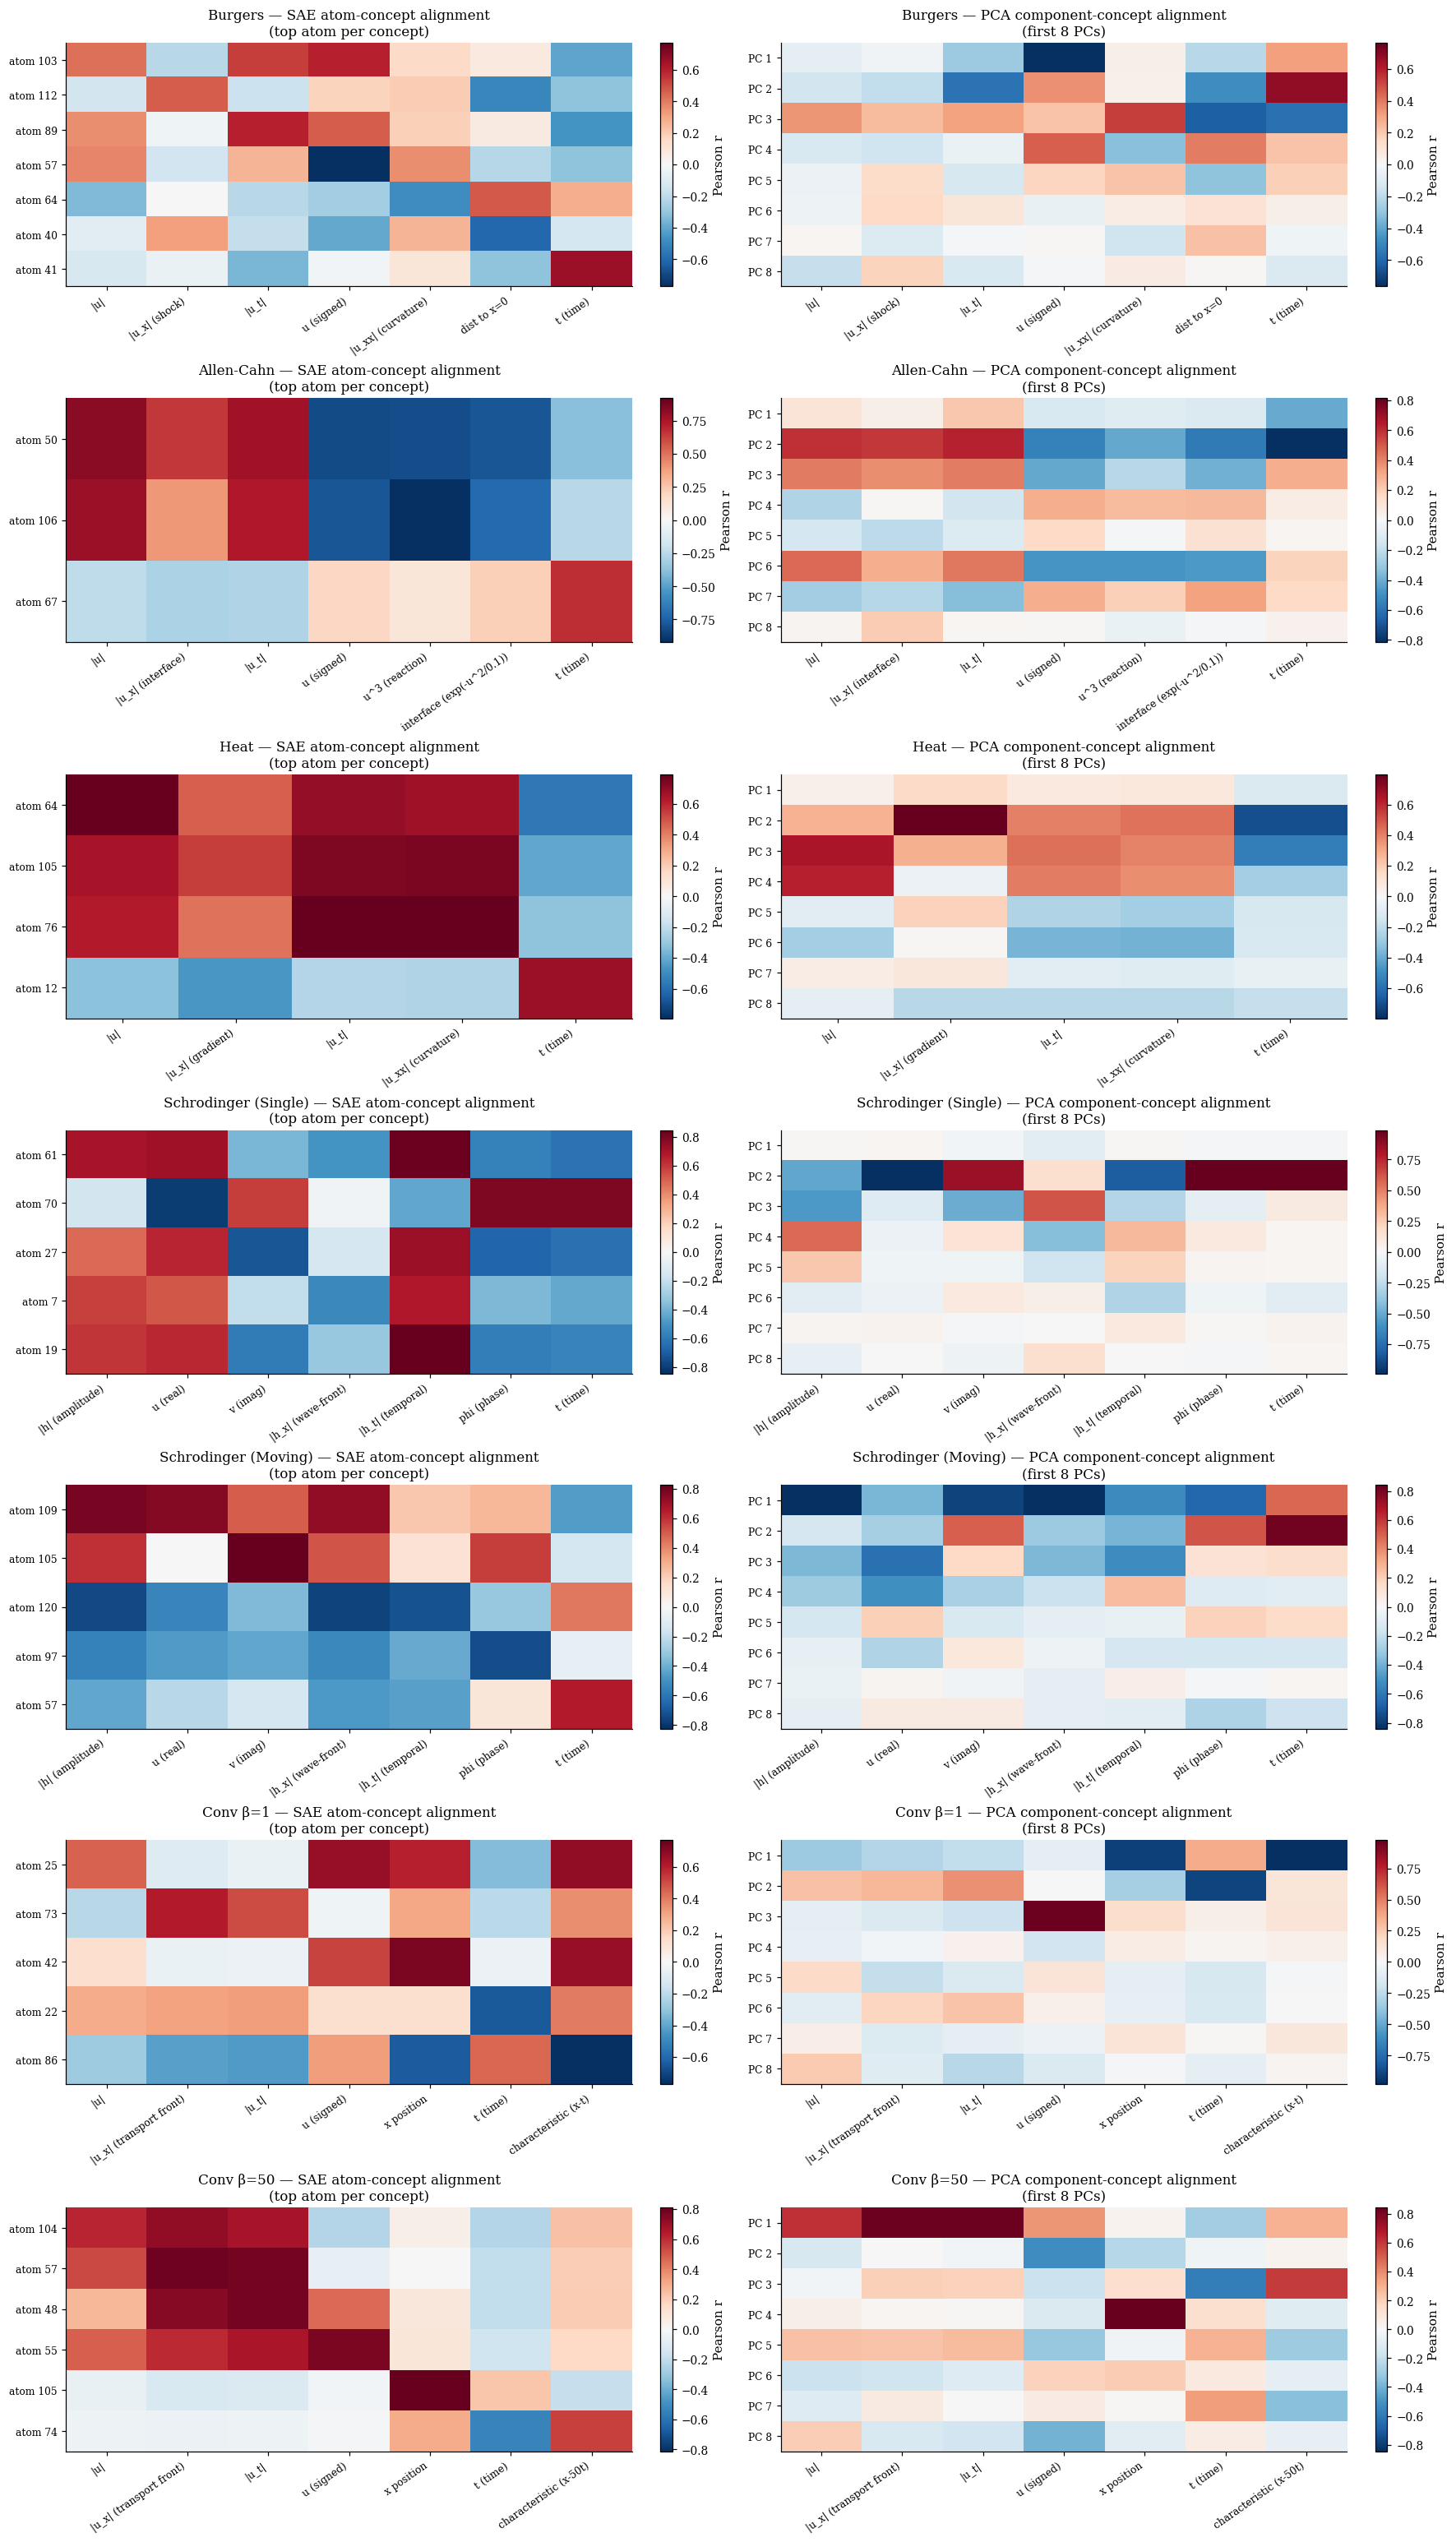

In [19]:
### Figure 2 — Alignment matrices, SAE vs PCA

def fig2(A_dict, A_pca_dict, names_dict):

    tags = ["Burgers","Allen-Cahn","Heat","Schrodinger (Single)","Schrodinger (Moving)","Conv β=1","Conv β=50"]
    fig, axes = plt.subplots(len(tags),2,figsize=(16, 28),constrained_layout=True)

    for row, tag in enumerate(tags):

        A = A_dict[tag]
        A_pca = A_pca_dict[tag]
        names = names_dict[tag]

        # ---------------- SAE ----------------

        rows = [int(np.argmax(np.abs(A[:, j])))for j in range(A.shape[1])]
        rows_u = list(dict.fromkeys(rows))
        A_show = A[rows_u]
        ax = axes[row,0]
        vmax = max(np.abs(A_show).max(), 1e-3)
        im = ax.imshow(A_show,cmap="RdBu_r",vmin=-vmax,vmax=vmax,aspect="auto")
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names,rotation=35,ha="right",fontsize=8)
        ax.set_yticks(range(len(rows_u)))
        ax.set_yticklabels([f"atom {k}" for k in rows_u],fontsize=8)
        ax.set_title(f"{tag} — SAE atom-concept alignment\n(top atom per concept)")
        plt.colorbar(im,ax=ax,fraction=0.04,label="Pearson r")

        # ---------------- PCA ----------------

        K_pca = min(8, A_pca.shape[0])
        ax = axes[row,1]
        vmax = max(np.abs(A_pca[:K_pca]).max(), 1e-3)
        im = ax.imshow(A_pca[:K_pca],cmap="RdBu_r",vmin=-vmax,vmax=vmax,aspect="auto")
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names,rotation=35,ha="right",fontsize=8)
        ax.set_yticks(range(K_pca))
        ax.set_yticklabels([f"PC {k+1}" for k in range(K_pca)],fontsize=8)
        ax.set_title(f"{tag} — PCA component-concept alignment\n(first {K_pca} PCs)")
        plt.colorbar(im,ax=ax,fraction=0.04,label="Pearson r")

    plt.savefig("figures/fig2_alignment.png",bbox_inches="tight")
    plt.show()


fig2(
    {"Burgers": A_b,"Allen-Cahn": A_a,"Heat": A_h,"Schrodinger (Single)": A_s_s,"Schrodinger (Moving)": A_s_m,"Conv β=1": A_c1,"Conv β=50": A_c50,},
    {"Burgers": A_pca_b,"Allen-Cahn": A_pca_a,"Heat": A_pca_h,"Schrodinger (Single)": A_pca_s_s,"Schrodinger (Moving)": A_pca_s_m,"Conv β=1": A_pca_c1,"Conv β=50": A_pca_c50,},
    {"Burgers": names_b,"Allen-Cahn": names_a,"Heat": names_h,"Schrodinger (Single)": names_s_s,"Schrodinger (Moving)": names_s_m,"Conv β=1": names_c1,"Conv β=50": names_c50,}
)

##  Spatial structure of the top atoms


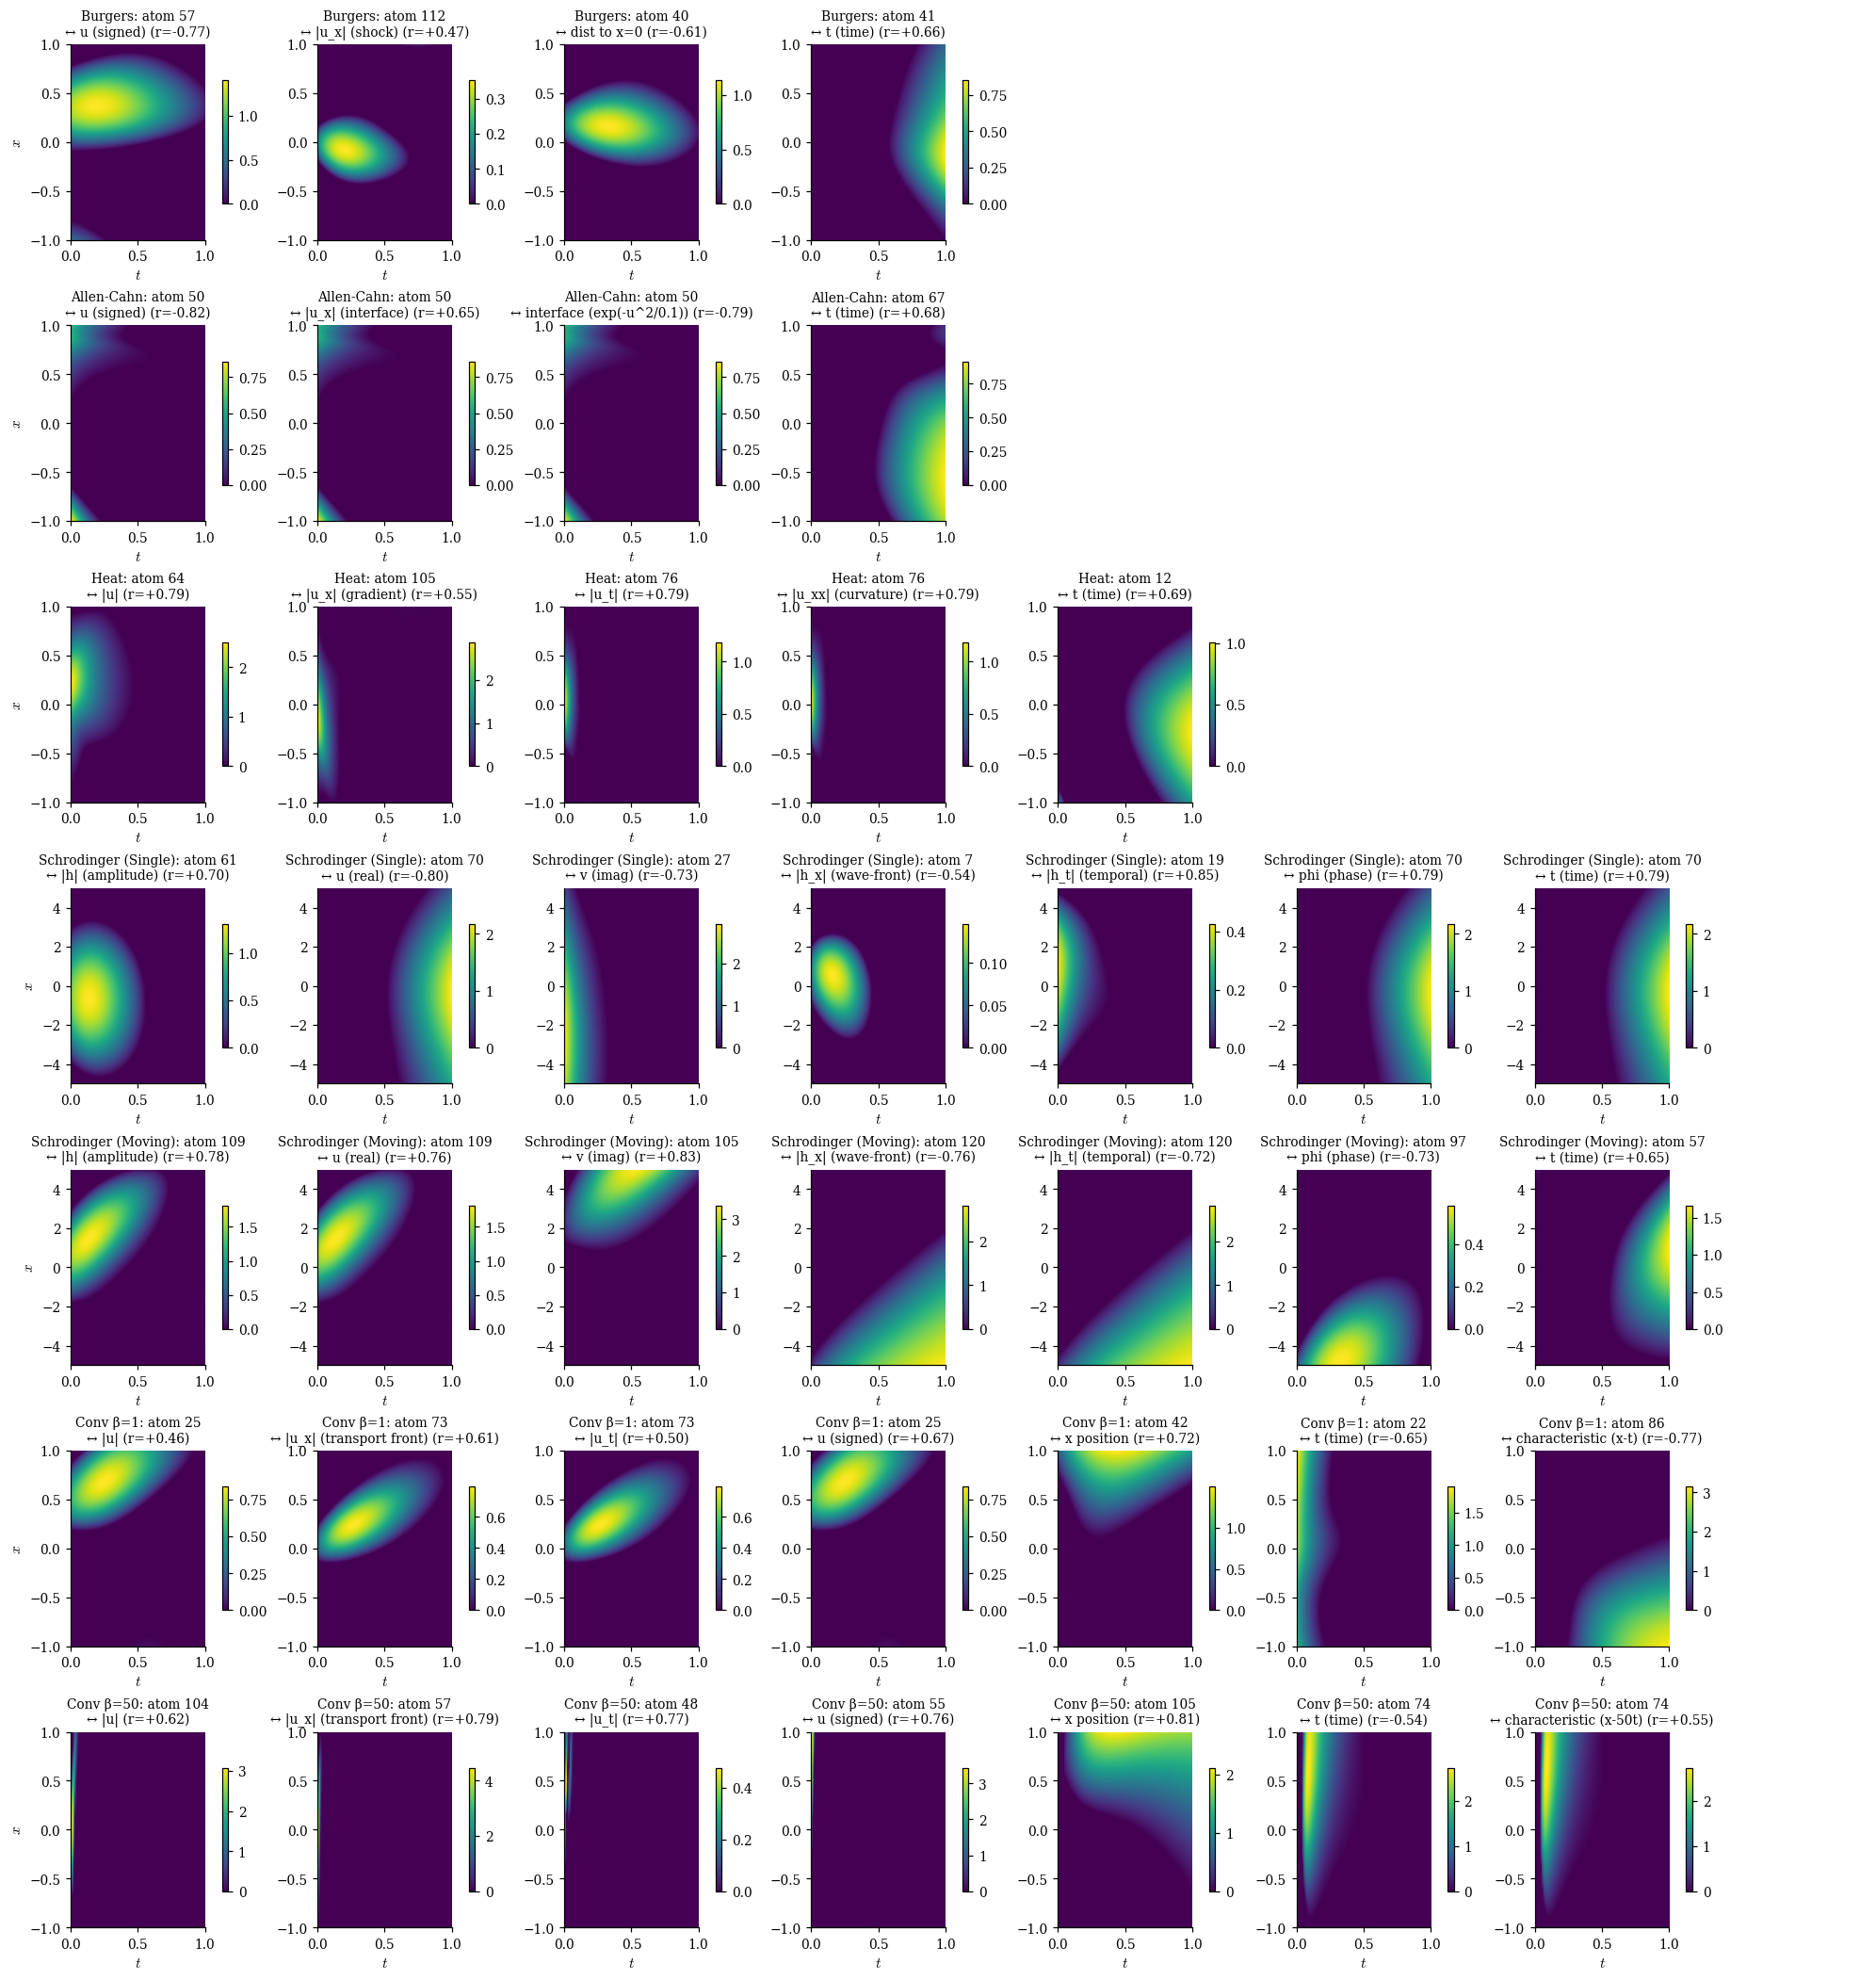

In [20]:
def fig3(d_list):

    fig, axes = plt.subplots(7,8,figsize=(18, 19),constrained_layout=True)
    for row, (Z, A, names, concept_subset, tag) in enumerate(d_list):
        current_extent = extent_s if "Schrodinger" in tag else extent
        for j_idx, cname in enumerate(concept_subset):

            j = names.index(cname)
            k_top = int(np.argmax(np.abs(A[:, j])))
            r = A[k_top, j]
            zk = Z[..., k_top]
            ax = axes[row, j_idx]
            vmax = zk.max()
            im = ax.imshow(zk,extent=current_extent,origin="lower",aspect="auto",cmap="viridis",vmin=0,vmax=vmax if vmax > 0 else 1)
            ax.set_title(f"{tag}: atom {k_top}\n↔ {cname} (r={r:+.2f})",fontsize=9)
            ax.set_xlabel("$t$")

            if j_idx == 0:
                ax.set_ylabel("$x$")

            plt.colorbar(im,ax=ax,fraction=0.046)

        # hide unused columns
        for k in range(len(concept_subset), 8):
            axes[row, k].axis("off")

    plt.savefig("figures/fig3_atoms.png",bbox_inches="tight")
    plt.show()


burgers_concepts_show = ["u (signed)","|u_x| (shock)","dist to x=0","t (time)"]
ac_concepts_show = ["u (signed)","|u_x| (interface)","interface (exp(-u^2/0.1))","t (time)"]
heat_concepts_show = ["|u|","|u_x| (gradient)","|u_t|","|u_xx| (curvature)","t (time)"]
sch_concepts_show = ["|h| (amplitude)","u (real)","v (imag)","|h_x| (wave-front)","|h_t| (temporal)","phi (phase)","t (time)"]
conv1_concepts_show = ["|u|","|u_x| (transport front)","|u_t|","u (signed)","x position","t (time)","characteristic (x-t)"]
conv50_concepts_show = ["|u|","|u_x| (transport front)","|u_t|","u (signed)","x position","t (time)","characteristic (x-50t)"]


fig3([(Z_b, A_b, names_b, burgers_concepts_show, "Burgers"),
      (Z_a, A_a, names_a,ac_concepts_show,"Allen-Cahn"),
      (Z_h, A_h, names_h,heat_concepts_show,"Heat"),
      (Z_s_s, A_s_s, names_s_s,sch_concepts_show,"Schrodinger (Single)"),
      (Z_s_m, A_s_m, names_s_m,sch_concepts_show,"Schrodinger (Moving)"),
      (Z_c1, A_c1, names_c1,conv1_concepts_show,"Conv β=1"),
      (Z_c50, A_c50, names_c50,conv50_concepts_show,"Conv β=50")])

# 9. Ablation — closed-loop causal check - Figure 4



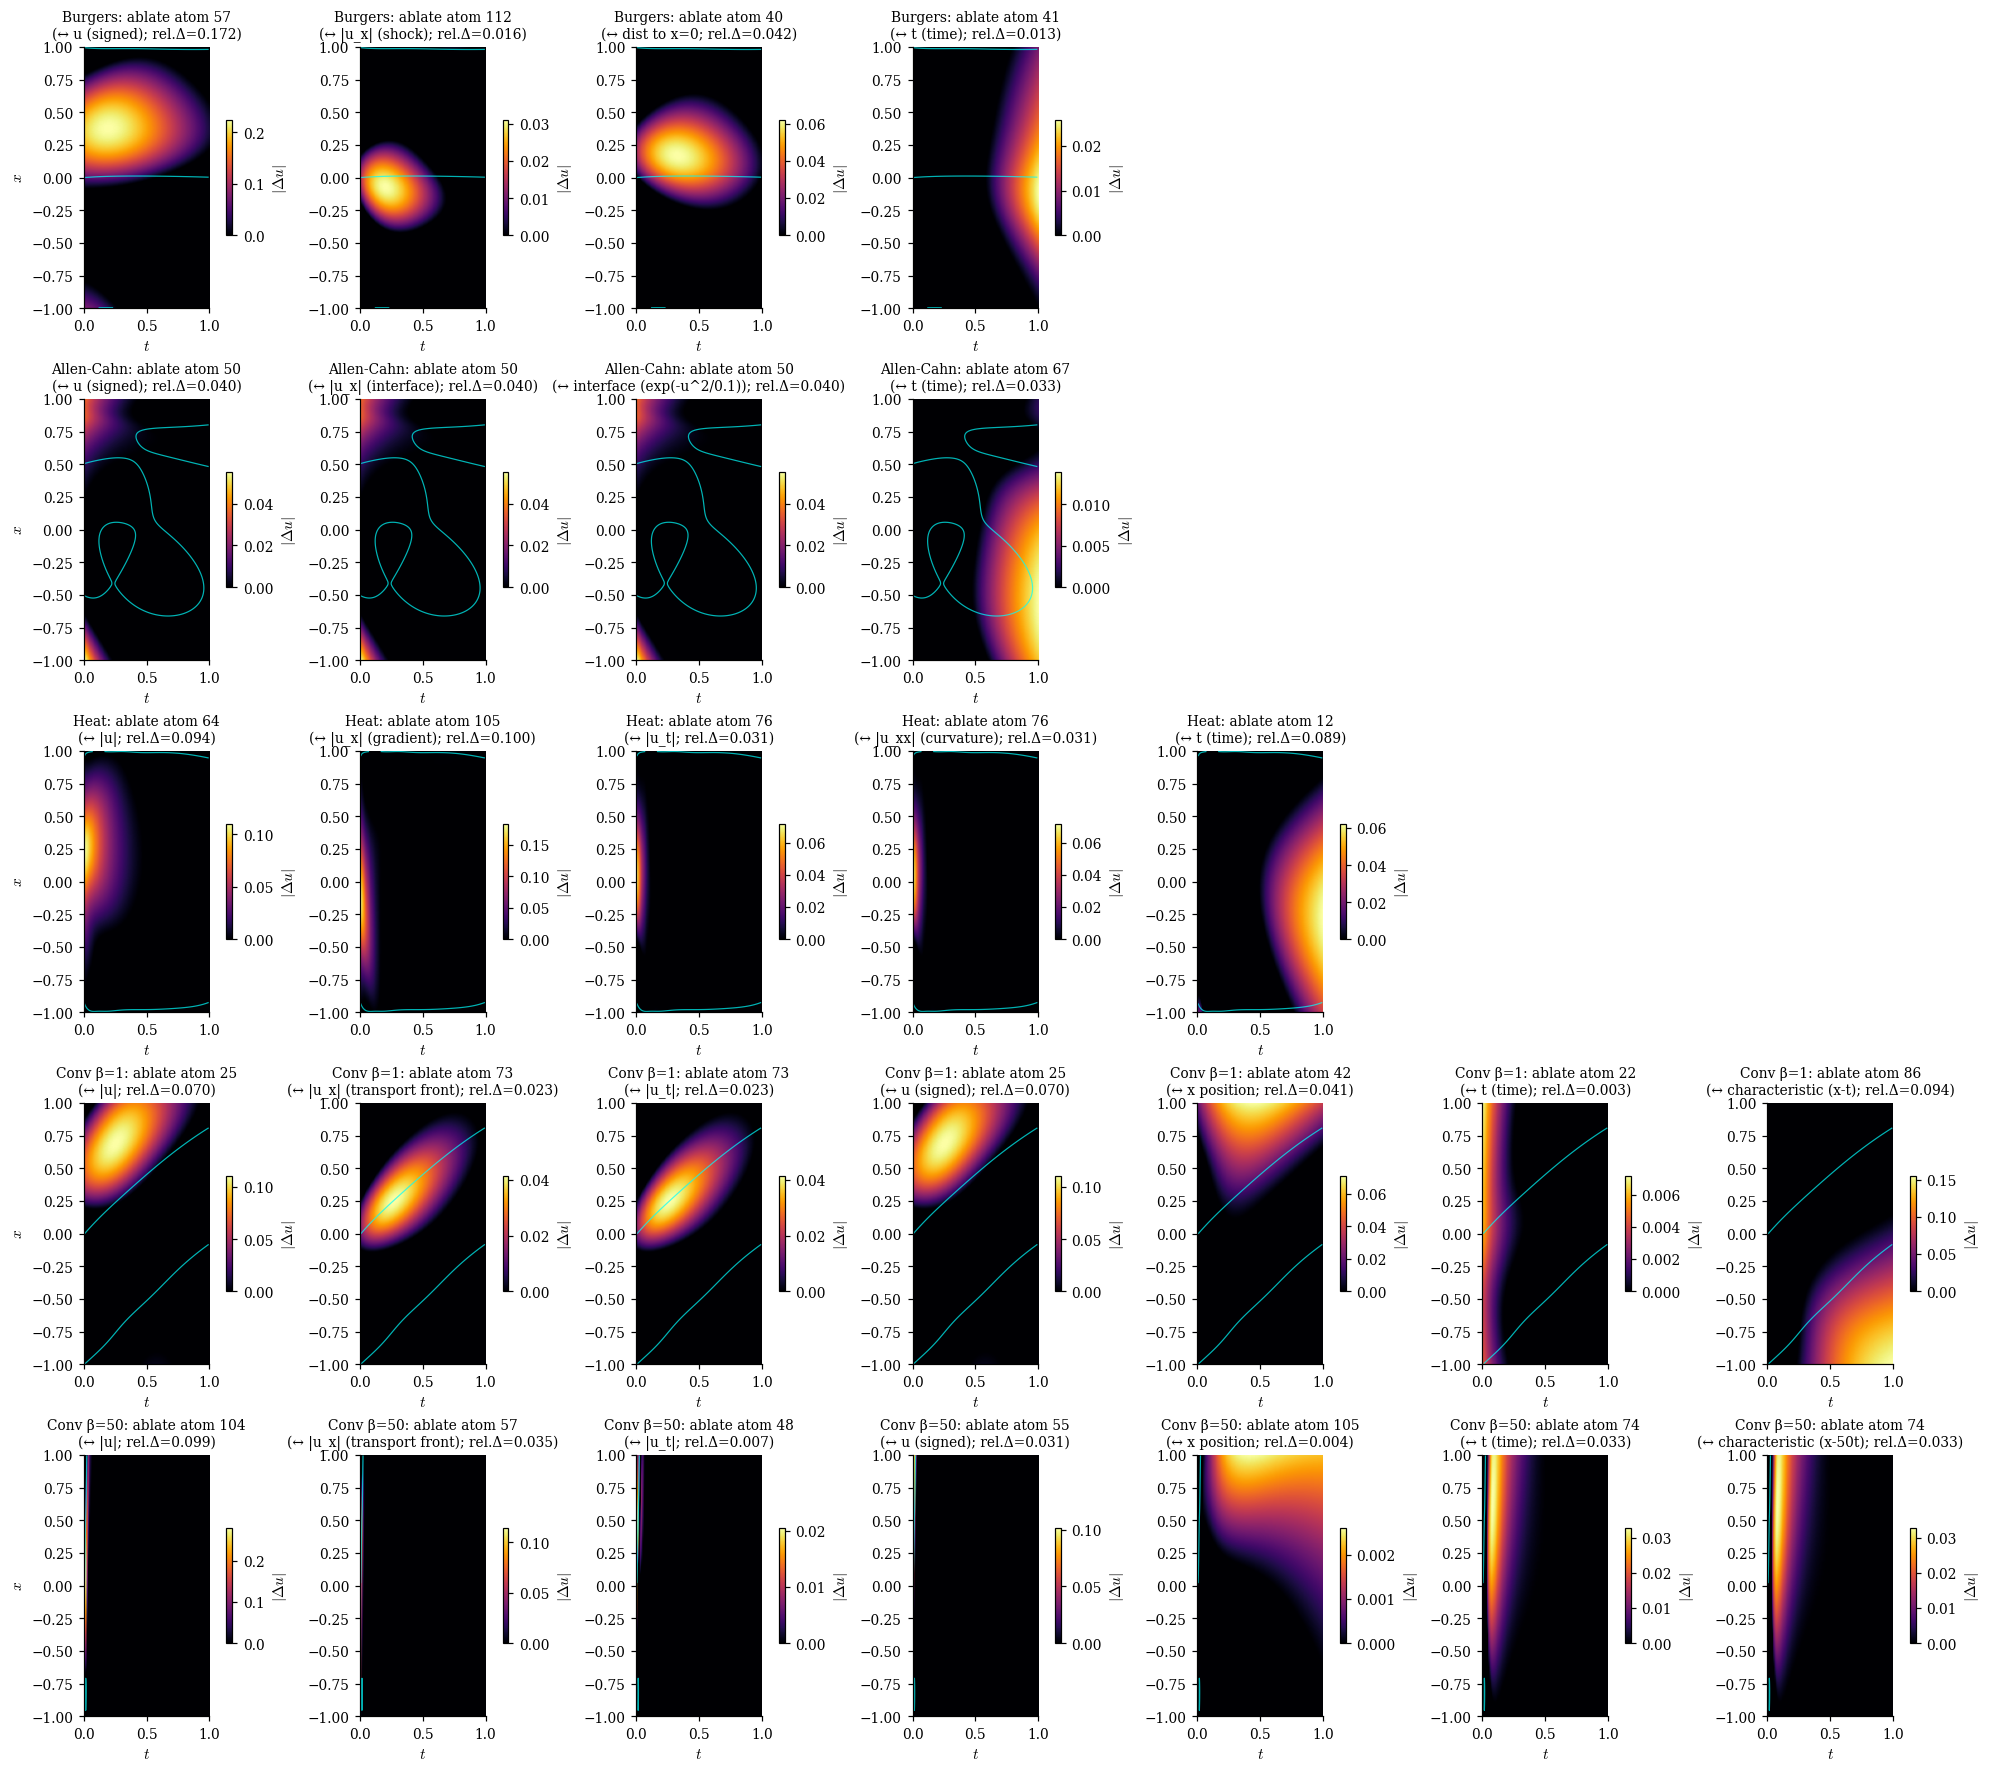

In [21]:
def intervene_ablate(pinn, sae, H, mu, sd, atom_idx):
    H_flat = H.reshape(-1, HIDDEN)
    H_n = (H_flat - mu)/sd
    Ht = torch.from_numpy(H_n).float()
    with torch.no_grad():
        z = sae.encode(Ht)
        h_recon_n = sae.decode(z).numpy()
        z_mod = z.clone(); z_mod[:, atom_idx] = 0.0
        h_mod_n = sae.decode(z_mod).numpy()
    h_recon = h_recon_n * sd + mu
    h_mod   = h_mod_n   * sd + mu
    W = pinn.net[-1].weight.detach().numpy(); b = pinn.net[-1].bias.detach().numpy()
    u_recon = (h_recon @ W.T + b).reshape(nx, nt)
    u_mod   = (h_mod   @ W.T + b).reshape(nx, nt)
    return u_recon, u_mod, u_recon - u_mod

def fig4(items):
    max_cols = 0
    for _, _, _, _, _, _, _, _, concepts_to_show, _ in items:
        if len(concepts_to_show) > max_cols:
            max_cols = len(concepts_to_show)

    fig, axes = plt.subplots(5, max_cols, figsize=(18, 16), constrained_layout=True)
    for row, (pinn, sae, H, mu, sd, A, names, U, concepts_to_show, tag) in enumerate(items):
        for j_idx, cname in enumerate(concepts_to_show):
            j = names.index(cname)
            k_top = int(np.argmax(np.abs(A[:, j])))
            u_recon, u_mod, delta = intervene_ablate(pinn, sae, H, mu, sd, k_top)
            ax = axes[row, j_idx]
            adelta = np.abs(delta); vmax = adelta.max()
            im = ax.imshow(adelta, extent=extent, origin="lower", aspect="auto",
                           cmap="inferno", vmin=0, vmax=vmax if vmax>0 else 1)
            ax.contour(U, levels=[0.0], extent=extent, origin="lower",
                       colors="cyan", linewidths=0.8, alpha=0.7)
            rel = np.linalg.norm(delta) / (np.linalg.norm(u_recon) + 1e-12)
            ax.set_title(f"{tag}: ablate atom {k_top}\n(↔ {cname}; rel.Δ={rel:.3f})", fontsize=9)
            ax.set_xlabel("$t$")
            if j_idx == 0: ax.set_ylabel("$x$")
            plt.colorbar(im, ax=ax, fraction=0.046, label=r"$|\Delta u|$")
        # Hide unused columns for this row if concepts_to_show is shorter than max_cols
        for k in range(len(concepts_to_show), max_cols):
            axes[row, k].axis("off")
    plt.savefig("figures/fig4_intervention.png", bbox_inches="tight"); plt.show()

fig4([
    (pinn_b, sae_b, H_b, mu_b, sd_b, A_b, names_b, U_b, burgers_concepts_show, "Burgers"),
    (pinn_a, sae_a, H_a, mu_a, sd_a, A_a, names_a, U_a, ac_concepts_show,      "Allen-Cahn"),
    (pinn_h,sae_h,H_h,mu_h,sd_h,A_h,names_h,U_h,heat_concepts_show,"Heat"),
    (conv_models[1], sae_c1, H_c1, mu_c1, sd_c1, A_c1, names_c1, U_c1,conv1_concepts_show, "Conv β=1"),
    (conv_models[50], sae_c50, H_c50, mu_c50, sd_c50, A_c50, names_c50, U_c50,conv50_concepts_show, "Conv β=50")
])

## ablation for schrodinger - single and moving soliton

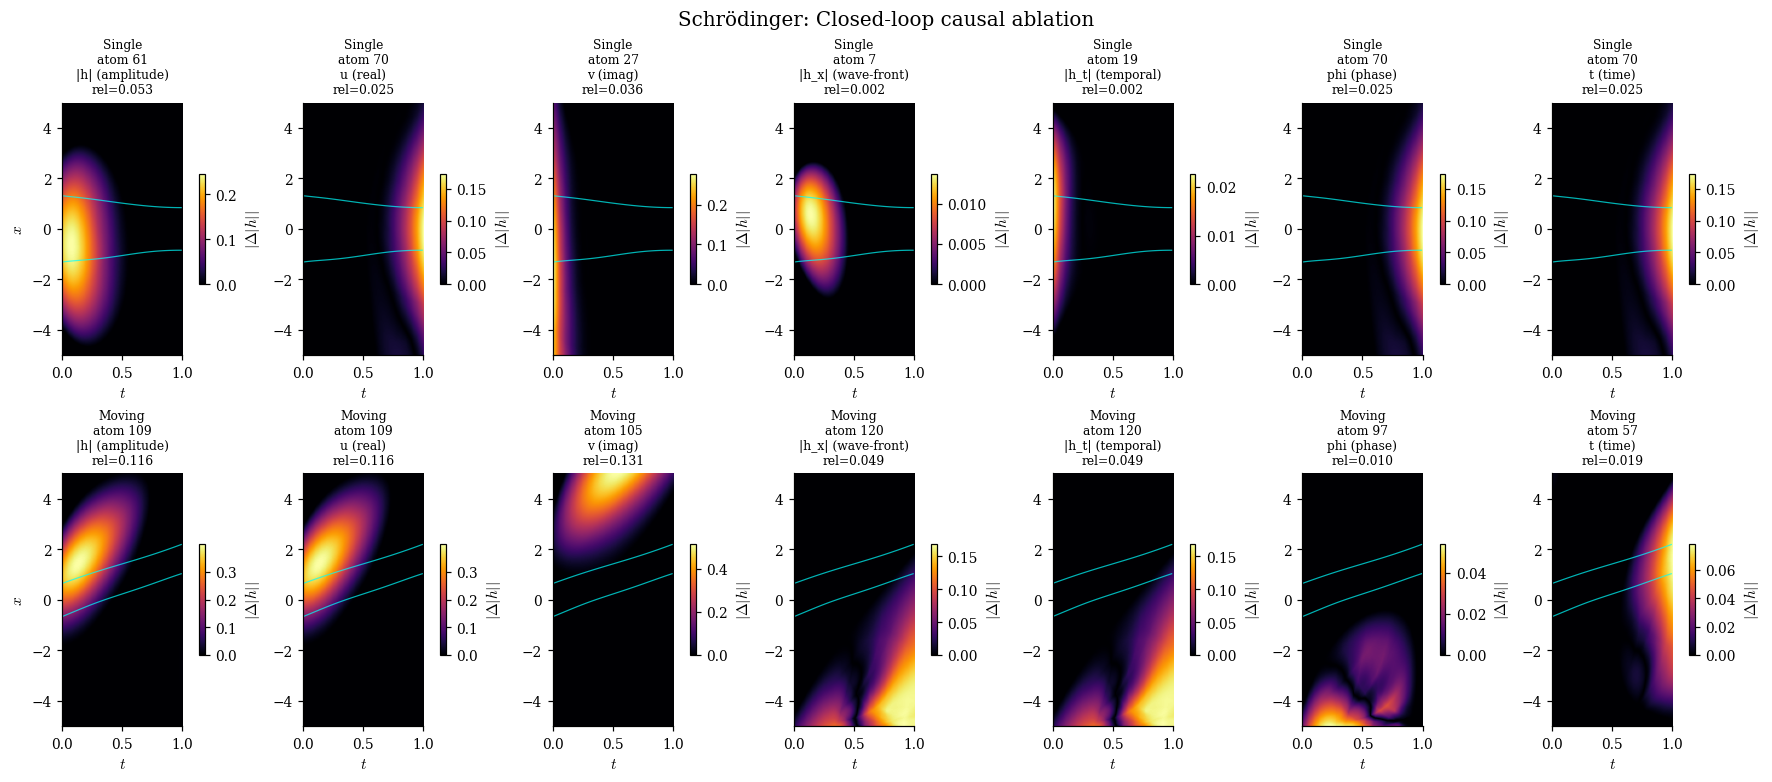

In [22]:
def intervene_ablate_schrodinger(pinn, sae, H, mu, sd, atom_idx):

    H_flat = H.reshape(-1, HIDDEN)
    H_n = (H_flat - mu)/sd
    Ht = torch.from_numpy(H_n).float()

    with torch.no_grad():
        z = sae.encode(Ht)
        z_mod = z.clone()
        z_mod[:,atom_idx] = 0.0
        h_recon_n = sae.decode(z).numpy()
        h_mod_n = sae.decode(z_mod).numpy()

    h_recon = h_recon_n*sd + mu
    h_mod = h_mod_n*sd + mu
    W = pinn.net[-1].weight.detach().numpy()
    b = pinn.net[-1].bias.detach().numpy()
    uv_recon = h_recon @ W.T + b
    uv_mod = h_mod @ W.T + b
    u_recon = uv_recon[:,0].reshape(nx,nt)
    v_recon = uv_recon[:,1].reshape(nx,nt)
    u_mod = uv_mod[:,0].reshape(nx,nt)
    v_mod = uv_mod[:,1].reshape(nx,nt)
    amp_recon = np.sqrt(u_recon**2 + v_recon**2)
    amp_mod = np.sqrt(u_mod**2 + v_mod**2)

    return amp_recon, amp_mod, amp_recon-amp_mod


extent_s = [0,1,-5,5]

fig, axes = plt.subplots(2, 7, figsize=(16,7), constrained_layout=True)

rows = [
    ("Single", pinn_s_s, sae_s_s, H_s_s, mu_s_s, sd_s_s,
     A_s_s, names_s_s, AMP_s_fig_single),

    ("Moving", pinn_s_m, sae_s_m, H_s_m, mu_s_m, sd_s_m,
     A_s_m, names_s_m, AMP_s_fig_moving)
]

for row,(tag,pinn,sae,H,mu,sd,A,names,AMP_fig) in enumerate(rows):

    for j_idx,cname in enumerate(sch_concepts_show):

        j = names.index(cname)
        k_top = int(np.argmax(np.abs(A[:,j])))

        amp_recon, amp_mod, delta = intervene_ablate_schrodinger(pinn, sae, H, mu, sd, k_top)
        ax = axes[row,j_idx]
        adelta = np.abs(delta)
        im = ax.imshow(adelta,extent=extent_s,origin="lower",aspect="auto",cmap="inferno",vmin=0,vmax=adelta.max() if adelta.max()>0 else 1)
        ax.contour(AMP_fig,levels=[1.0],extent=extent_s,origin="lower",colors="cyan",linewidths=0.8,alpha=0.7)
        rel = np.linalg.norm(delta)/(np.linalg.norm(amp_recon)+1e-12)

        ax.set_title(f"{tag}\natom {k_top}\n{cname}\nrel={rel:.3f}",fontsize=8)
        ax.set_xlabel("$t$")

        if j_idx==0:
            ax.set_ylabel("$x$")

        plt.colorbar(im,ax=ax,fraction=0.046,label=r"$|\Delta |h||$")

plt.suptitle("Schrödinger: Closed-loop causal ablation",fontsize=13)
plt.savefig("figures/fig4_schrodinger_intervention.png",bbox_inches="tight")
plt.show()

# 10. Figure 5 — Training dynamics and SAE-vs-PCA bar chart

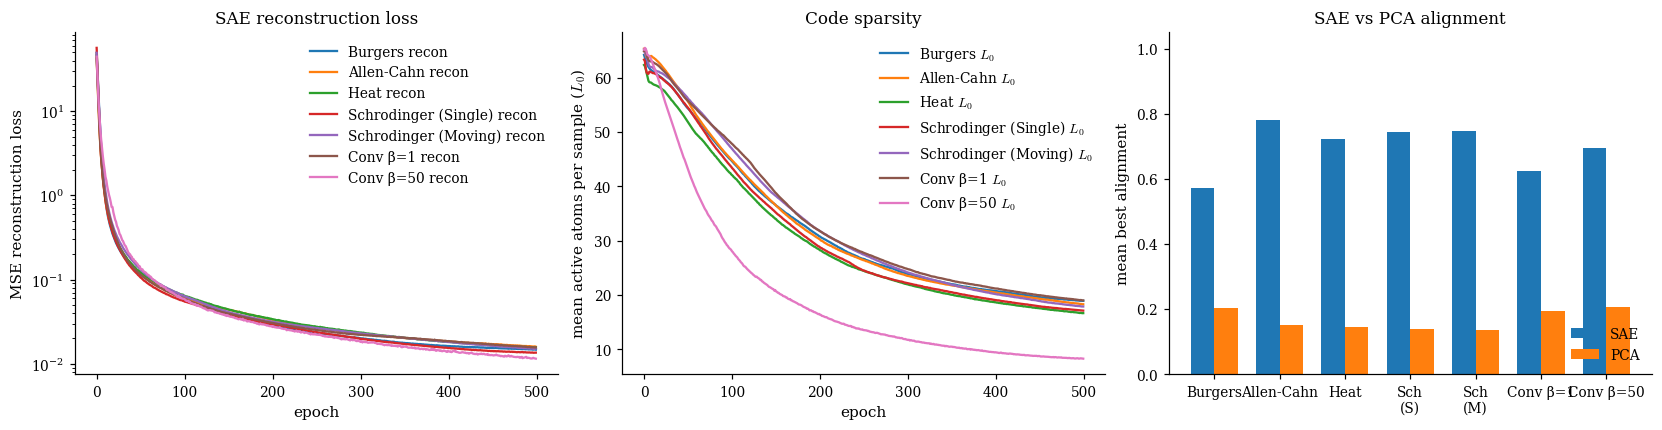

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15.0, 3.8), constrained_layout=True)

# Reconstruction loss

ax = axes[0]

ax.plot(sae_hist_b[:,1], label="Burgers recon")
ax.plot(sae_hist_a[:,1], label="Allen-Cahn recon")
ax.plot(sae_hist_h[:,1], label="Heat recon")
ax.plot(sae_hist_s_s[:,1], label="Schrodinger (Single) recon")
ax.plot(sae_hist_s_m[:,1], label="Schrodinger (Moving) recon")
ax.plot(sae_hist_c1[:,1], label="Conv β=1 recon")
ax.plot(sae_hist_c50[:,1], label="Conv β=50 recon")

ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE reconstruction loss")
ax.set_title("SAE reconstruction loss")
ax.legend(frameon=False)


# Code sparsity

ax = axes[1]

ax.plot(sae_hist_b[:,3], label="Burgers $L_0$")
ax.plot(sae_hist_a[:,3], label="Allen-Cahn $L_0$")
ax.plot(sae_hist_h[:,3], label="Heat $L_0$")
ax.plot(sae_hist_s_s[:,3], label="Schrodinger (Single) $L_0$")
ax.plot(sae_hist_s_m[:,3], label="Schrodinger (Moving) $L_0$")
ax.plot(sae_hist_c1[:,3], label="Conv β=1 $L_0$")
ax.plot(sae_hist_c50[:,3], label="Conv β=50 $L_0$")

ax.set_xlabel("epoch")
ax.set_ylabel(r"mean active atoms per sample ($L_0$)")
ax.set_title("Code sparsity")
ax.legend(frameon=False)



# SAE vs PCA

ax = axes[2]

tags = [
    "Burgers",
    "Allen-Cahn",
    "Heat",
    "Sch\n(S)",
    "Sch\n(M)",
    "Conv β=1",
    "Conv β=50"
]

sae_scores = [
    np.max(np.abs(A_b), axis=0).mean(),
    np.max(np.abs(A_a), axis=0).mean(),
    np.max(np.abs(A_h), axis=0).mean(),
    np.max(np.abs(A_s_s), axis=0).mean(),
    np.max(np.abs(A_s_m), axis=0).mean(),
    np.max(np.abs(A_c1), axis=0).mean(),
    np.max(np.abs(A_c50), axis=0).mean()
]

pca_scores = [
    np.max(np.abs(A_pca_b), axis=1).mean(),
    np.max(np.abs(A_pca_a), axis=1).mean(),
    np.max(np.abs(A_pca_h), axis=1).mean(),
    np.max(np.abs(A_pca_s_s), axis=1).mean(),
    np.max(np.abs(A_pca_s_m), axis=1).mean(),
    np.max(np.abs(A_pca_c1), axis=1).mean(),
    np.max(np.abs(A_pca_c50), axis=1).mean()
]

xb = np.arange(len(tags))

ax.bar(xb-0.18, sae_scores, width=0.36, label="SAE")
ax.bar(xb+0.18, pca_scores, width=0.36, label="PCA")

ax.set_xticks(xb)
ax.set_xticklabels(tags)
ax.set_ylim(0, 1.05)
ax.set_ylabel("mean best alignment")
ax.set_title("SAE vs PCA alignment")
ax.legend(frameon=False, loc="lower right")

plt.savefig(
    "figures/fig5_sparsity_baseline.png",
    bbox_inches="tight"
)

plt.show()

# 11. Qualitative eval

In [24]:
import pandas as pd
import numpy as np
import torch


# ============================================================
# Quantitative evaluation metrics
# ============================================================

def reconstruction_error(model, Hraw):

    H = torch.from_numpy(Hraw.reshape(-1, HIDDEN)).float()

    with torch.no_grad():
        z = model.encode(H)
        H_hat = model.decode(z)
        recon = ((H_hat - H)**2).mean().item()

    return recon


def mean_l0(model, Hraw):

    H = torch.from_numpy(Hraw.reshape(-1, HIDDEN)).float()

    with torch.no_grad():
        z = model.encode(H)
        return (z > 1e-6).float().sum(dim=1).mean().item()


def mean_l1(model, Hraw):

    H = torch.from_numpy(Hraw.reshape(-1, HIDDEN)).float()

    with torch.no_grad():
        z = model.encode(H)
        return z.abs().sum(dim=1).mean().item()


def alignment_score(A):
    """
    Mean best concept alignment across atoms.
    """
    return np.max(np.abs(A), axis=1).mean()


# ============================================================
# Models to evaluate
# ============================================================

rows = [
    ("Burgers",        sae_b,    H_b_n,    hist_b,          A_b),
    ("Allen-Cahn",     sae_a,    H_a_n,    hist_a,          A_a),
    ("Heat",           sae_h,    H_h_n,    hist_h,          A_h),
    ("Schr (Single)",  sae_s_s,  H_s_s_n,  hist_s_s,        A_s_s),
    ("Schr (Moving)",  sae_s_m,  H_s_m_n,  hist_s_m,        A_s_m),
    ("Conv β=1",       sae_c1,   H_c1_n,   conv_hists[1],   A_c1),
    ("Conv β=50",      sae_c50,  H_c50_n,  conv_hists[50],  A_c50),
]


# ============================================================
# Build quantitative table
# ============================================================

table = []

for name, model, Hraw, hist, A in rows:

    bc, ic, residual = hist[-1]

    # True PINN objective (without sparse penalty)
    final_pinn_loss = 100 * bc + 100 * ic + residual

    table.append({
        "PDE": name,
        "Final PINN Loss": final_pinn_loss,
        "Mean L1": mean_l1(model, Hraw),
        "Mean L0": mean_l0(model, Hraw),
        "Hidden Recon MSE": reconstruction_error(model, Hraw),
        "Alignment": alignment_score(A),
    })


# ============================================================
# Display table
# ============================================================

df = pd.DataFrame(table)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.precision", 4)

print("\n================ Quantitative Evaluation ================\n")
print(df)

# Save
df.to_csv("artifacts/quantitative_evaluation.csv", index=False)

print("\nSaved to:")
print("artifacts/quantitative_evaluation.csv")


================ Quantitative Evaluation ================

             PDE  Final PINN Loss  Mean L1  Mean L0  Hidden Recon MSE  Alignment
0        Burgers           0.4742   7.9777  18.9057            0.0004     0.3521
1     Allen-Cahn           1.0839   7.3025  18.3022            0.0004     0.3576
2           Heat           0.0149   6.6675  16.6471            0.0004     0.3380
3  Schr (Single)           0.1479   7.7275  17.1382            0.0003     0.3094
4  Schr (Moving)           0.0711   7.3857  17.8537            0.0004     0.3837
5       Conv β=1           0.3226   7.7481  19.0286            0.0004     0.3742
6      Conv β=50           7.5370   3.4609   8.2806            0.0003     0.4127

Saved to:
artifacts/quantitative_evaluation.csv
